# HadithMisinfoBench — ICCIT 2026 Experimental Notebook

This edited notebook implements the revised six-page ICCIT 2026 experimental design.

## Primary retrieval benchmark
Evaluate canonical evidence retrieval on all authentic claims with source-associated gold evidence:
- BM25 English reference
- BM25 direct Bangla
- BGE-M3, mE5-Large, LaBSE, multilingual MiniLM
- RRF(BM25-English + BGE-M3)
- RRF(BM25-English + mE5-Large)
- **RRF(BM25-English + LaBSE)**

LaBSE is explicitly tested in RRF because it is the strongest standalone multilingual retriever in the current manuscript. This prevents the reviewer-visible problem of reporting LaBSE as the best standalone model while never testing whether it benefits from fusion.

MiniLM is retained as a standalone baseline. Its near-zero retrieval performance is reported rather than hidden, but it is not treated as a serious RRF candidate.

## Secondary 100-claim end-to-end experiment
A fixed subset selected with **random seed 42** compares:
1. Bangla → LLM translation → BM25 → LLM assessment
2. Bangla → BGE-M3 → LLM assessment

The same claims, evidence corpus, top-five context, and assessor are used for both pipelines. LLM outputs are cached.


## Experimental rationale

The revised notebook closes three reviewer-visible gaps:

1. **Translation baseline:** explicitly tests Bangla → English → BM25.
2. **LaBSE fusion:** tests RRF with LaBSE because LaBSE is a strong standalone retriever.
3. **MiniLM failure:** retains MiniLM as a negative/lightweight baseline but does not use a near-zero retriever as a hybrid candidate.

RRF candidates are evaluated transparently rather than chosen to force a desired result. If LaBSE-RRF is strongest, the manuscript should report LaBSE-RRF. If LaBSE-RRF is weaker despite stronger standalone retrieval, that is itself an informative result about ranking complementarity.


In [1]:
!pip -q install "sentence-transformers>=3.0" "torch>=2.0" rank-bm25 tqdm numpy pandas openai scipy scikit-learn

import os, re, json, gc, random, hashlib, warnings
from dataclasses import dataclass
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
warnings.filterwarnings("ignore")
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
os.environ["PYTORCH_CUDA_ALLOC_CONF"]="expandable_segments:True"
DEVICE="cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE=="cuda": print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


## 1. Upload benchmark and evidence files

Required: `evidence.jsonl`, `benchmark_dataset_a.jsonl`

Optional: `s4_trans.jsonl` — existing translation artifacts from the earlier experiment.


In [2]:
from google.colab import files
os.makedirs("data/processed", exist_ok=True)
os.makedirs("data/indices/dense", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)
os.makedirs("results/cache", exist_ok=True)
print("Upload evidence.jsonl, benchmark_dataset_a.jsonl, and optionally s4_trans.jsonl")
uploaded=files.upload()
for fname,data in uploaded.items():
    if fname=="evidence.jsonl": Path("data/processed/evidence.jsonl").write_bytes(data)
    elif "benchmark_dataset" in fname: Path("data/processed/benchmark_dataset_a.jsonl").write_bytes(data)
    elif "s4_trans" in fname: Path("results/s4_trans.jsonl").write_bytes(data)
print("Uploaded:", list(uploaded.keys()))


Upload evidence.jsonl, benchmark_dataset_a.jsonl, and optionally s4_trans.jsonl


Saving benchmark_dataset_a.jsonl to benchmark_dataset_a.jsonl
Saving evidence.jsonl to evidence.jsonl
Uploaded: ['benchmark_dataset_a.jsonl', 'evidence.jsonl']


In [3]:
@dataclass
class EvidenceRecord:
    evidence_id: str; collection: str; book: str; reference: str; arabic_matn: str; english_text: str|None; grade: str|None=None
    def retrieval_text(self, mode="arabic_plus_english"):
        if mode=="arabic_only": return self.arabic_matn
        if mode=="english_only": return self.english_text or self.arabic_matn
        return "\n".join([self.arabic_matn]+(([self.english_text]) if self.english_text else []))
    @classmethod
    def from_dict(cls,d):
        return cls(d["evidence_id"],d["collection"],d.get("book",""),d.get("reference",""),d["arabic_matn"],d.get("english_text"),d.get("grade"))

@dataclass
class BenchmarkRecord:
    claim_id: str; source_id: str; label: str; claims: dict; canonical: dict; gold_evidence_ids: list
    @classmethod
    def from_dict(cls,d):
        return cls(d["claim_id"],d["source_id"],d["label"],d["claims"],d.get("canonical",{}),d.get("gold_evidence_ids",[]))

evidence_records=[EvidenceRecord.from_dict(json.loads(l)) for l in open("data/processed/evidence.jsonl",encoding="utf-8") if l.strip()]
evidence_ids_list=[r.evidence_id for r in evidence_records]
evidence_by_id={r.evidence_id:r for r in evidence_records}
benchmark=[BenchmarkRecord.from_dict(json.loads(l)) for l in open("data/processed/benchmark_dataset_a.jsonl",encoding="utf-8") if l.strip()]
auth_records=[r for r in benchmark if r.label=="authentic"]
fab_records=[r for r in benchmark if r.label=="fabricated"]
auth_with_gold=[r for r in auth_records if r.gold_evidence_ids]
gold_ids={r.claim_id:r.gold_evidence_ids for r in auth_with_gold}
print(f"Evidence records: {len(evidence_records):,}")
print(f"Benchmark: {len(benchmark):,}; authentic={len(auth_records):,}; fabricated={len(fab_records):,}")
print(f"Authentic with gold evidence: {len(auth_with_gold):,}")


Evidence records: 14,940
Benchmark: 2,000; authentic=986; fabricated=1,014
Authentic with gold evidence: 986


## 2. Dense retriever configuration

All four multilingual models are evaluated directly with Bangla queries. Evidence representations are fixed as Arabic Matn plus English translation. mE5 receives its required query/passage prefixes.


In [4]:
DENSE_MODELS={
 "bge-m3":{"hf_id":"BAAI/bge-m3","prefix_doc":"","prefix_query":"","desc":"BGE-M3 (568M, 1024-dim)"},
 "me5-large":{"hf_id":"intfloat/multilingual-e5-large","prefix_doc":"passage: ","prefix_query":"query: ","desc":"Multilingual-E5-Large (560M, 1024-dim)"},
 "labse":{"hf_id":"sentence-transformers/LaBSE","prefix_doc":"","prefix_query":"","desc":"LaBSE (471M, 768-dim)"},
 "minilm":{"hf_id":"sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2","prefix_doc":"","prefix_query":"","desc":"Multilingual-MiniLM (117M, 384-dim)"},
}
INDEX_DIR=Path("data/indices/dense")
CHUNK_SIZE=250; BATCH_SIZE_DOC=16; BATCH_SIZE_QUERY=32; MAX_SEQ_LEN_DOC=512; MAX_SEQ_LEN_QUERY=256

def load_model(key,max_seq_len):
    cfg=DENSE_MODELS[key]
    kwargs={"torch_dtype":torch.float16} if DEVICE=="cuda" else {}
    model=SentenceTransformer(cfg["hf_id"],device=DEVICE,model_kwargs=kwargs)
    model.max_seq_length=max_seq_len
    return model


In [5]:
dense_indices={}
for key,cfg in DENSE_MODELS.items():
    print("="*80); print(cfg["desc"])
    model_dir=INDEX_DIR/key; model_dir.mkdir(parents=True,exist_ok=True)
    emb_path=model_dir/"embeddings.npy"
    if emb_path.exists():
        embeddings=np.load(emb_path)
        if len(embeddings)==len(evidence_records):
            print("Loaded cached:",embeddings.shape); dense_indices[key]=embeddings.astype(np.float32); continue
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    model=load_model(key,MAX_SEQ_LEN_DOC)
    texts=[cfg["prefix_doc"]+r.retrieval_text("arabic_plus_english") for r in evidence_records]
    chunks=[]
    for i in range(0,len(texts),CHUNK_SIZE):
        print(f"Encoding {i+1}-{min(i+CHUNK_SIZE,len(texts))}/{len(texts)}")
        with torch.inference_mode(): emb=model.encode(texts[i:i+CHUNK_SIZE],normalize_embeddings=True,batch_size=BATCH_SIZE_DOC,show_progress_bar=False)
        chunks.append(np.asarray(emb,dtype=np.float32))
    embeddings=np.vstack(chunks); np.save(emb_path,embeddings)
    json.dump(evidence_ids_list,open(model_dir/"evidence_ids.json","w",encoding="utf-8"))
    json.dump({"model_name":cfg["hf_id"],"mode":"arabic_plus_english"},open(model_dir/"meta.json","w",encoding="utf-8"),indent=2)
    dense_indices[key]=embeddings
    del model; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
print("All dense indices ready.")


BGE-M3 (568M, 1024-dim)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 9.08MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 1-250/14940
Encoding 251-500/14940
Encoding 501-750/14940
Encoding 751-1000/14940
Encoding 1001-1250/14940
Encoding 1251-1500/14940
Encoding 1501-1750/14940
Encoding 1751-2000/14940
Encoding 2001-2250/14940
Encoding 2251-2500/14940
Encoding 2501-2750/14940
Encoding 2751-3000/14940
Encoding 3001-3250/14940
Encoding 3251-3500/14940
Encoding 3501-3750/14940
Encoding 3751-4000/14940
Encoding 4001-4250/14940
Encoding 4251-4500/14940
Encoding 4501-4750/14940
Encoding 4751-5000/14940
Encoding 5001-5250/14940
Encoding 5251-5500/14940
Encoding 5501-5750/14940
Encoding 5751-6000/14940
Encoding 6001-6250/14940
Encoding 6251-6500/14940
Encoding 6501-6750/14940
Encoding 6751-7000/14940
Encoding 7001-7250/14940
Encoding 7251-7500/14940
Encoding 7501-7750/14940
Encoding 7751-8000/14940
Encoding 8001-8250/14940
Encoding 8251-8500/14940
Encoding 8501-8750/14940
Encoding 8751-9000/14940
Encoding 9001-9250/14940
Encoding 9251-9500/14940
Encoding 9501-9750/14940
Encoding 9751-10000/14940
Encoding

In [11]:
# ============================================================
# BM25
# ============================================================

def tokenize(text):
    return re.findall(
        r"[\w\u0600-\u06FF\u0980-\u09FF]+",
        (text or "").lower()
    )


corpus_tokens = [
    tokenize(r.retrieval_text("arabic_plus_english"))
    for r in evidence_records
]

bm25 = BM25Okapi(corpus_tokens)


def bm25_search(query, k=10):
    scores = bm25.get_scores(tokenize(query))
    top = np.argsort(-scores)[:k]

    return [
        (
            evidence_ids_list[i],
            float(scores[i])
        )
        for i in top
    ]


# ============================================================
# MEMORY-SAFE DENSE RETRIEVAL
# ============================================================

def dense_search(
    model_key,
    queries,
    top_k=10,
    query_chunk_size=32
):
    """
    Memory-safe dense retrieval.

    Queries are encoded in chunks.
    Similarity is calculated against the dense evidence
    index one query at a time.
    """

    cfg = DENSE_MODELS[model_key]
    d = dense_indices[model_key]

    all_results = {}

    print(
        f"Running {cfg['desc']} "
        f"on {len(queries):,} queries..."
    )

    # --------------------------------------------------------
    # Load model
    # --------------------------------------------------------

    model = load_model(
        model_key,
        MAX_SEQ_LEN_QUERY
    )

    # --------------------------------------------------------
    # Process queries in chunks
    # --------------------------------------------------------

    for start in range(
        0,
        len(queries),
        query_chunk_size
    ):

        end = min(
            start + query_chunk_size,
            len(queries)
        )

        batch_queries = queries[start:end]

        prefixed = [
            cfg["prefix_query"] + (q or "")
            for q in batch_queries
        ]

        # ----------------------------------------------------
        # Encode query chunk
        # ----------------------------------------------------

        with torch.inference_mode():

            q_batch = model.encode(
                prefixed,
                normalize_embeddings=True,
                batch_size=BATCH_SIZE_QUERY,
                show_progress_bar=False
            )

        q_batch = np.asarray(
            q_batch,
            dtype=np.float32
        )

        # ----------------------------------------------------
        # Retrieve top-k for each query
        # ----------------------------------------------------

        for local_i in range(len(q_batch)):

            scores = q_batch[local_i] @ d.T

            k = min(
                top_k,
                len(scores)
            )

            # Efficient top-k selection
            top_idx = np.argpartition(
                -scores,
                k - 1
            )[:k]

            # Sort selected candidates
            top_idx = top_idx[
                np.argsort(
                    -scores[top_idx]
                )
            ]

            global_i = start + local_i

            all_results[global_i] = [
                (
                    evidence_ids_list[j],
                    float(scores[j])
                )
                for j in top_idx
            ]

        # ----------------------------------------------------
        # Cleanup
        # ----------------------------------------------------

        del q_batch

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        print(
            f"  Processed "
            f"{end:,}/{len(queries):,}"
        )

    # --------------------------------------------------------
    # Cleanup model
    # --------------------------------------------------------

    del model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return all_results


# ============================================================
# RRF
# ============================================================

def rrf_fuse(
    ranked_lists,
    top_k=10,
    k_rrf=60
):
    scores = {}

    for ranked in ranked_lists:

        for rank, (eid, _) in enumerate(
            ranked,
            start=1
        ):

            scores[eid] = (
                scores.get(eid, 0.0)
                + 1.0 / (k_rrf + rank)
            )

    return sorted(
        scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_k]


# ============================================================
# RECALL@K
# ============================================================

def recall_at_k(
    results_by_claim,
    gold,
    k
):
    if not gold:
        return 0.0

    hits = 0

    for cid in gold:

        retrieved = results_by_claim.get(
            cid,
            []
        )[:k]

        if any(
            eid in gold[cid]
            for eid, _ in retrieved
        ):
            hits += 1

    return hits / len(gold)


# ============================================================
# MRR
# ============================================================

def mrr(
    results_by_claim,
    gold
):
    vals = []

    for cid, gold_eids in gold.items():

        rr = 0.0

        for rank, (eid, _) in enumerate(
            results_by_claim.get(cid, []),
            start=1
        ):

            if eid in gold_eids:
                rr = 1.0 / rank
                break

        vals.append(rr)

    return float(
        np.mean(vals)
    ) if vals else 0.0


print("Retrieval functions loaded successfully.")

Retrieval functions loaded successfully.


In [12]:
print("BM25 corpus:", len(corpus_tokens))
print("Dense models:", list(DENSE_MODELS.keys()))
print("Dense indices:", {
    k: v.shape for k, v in dense_indices.items()
})

BM25 corpus: 14940
Dense models: ['bge-m3', 'me5-large', 'labse', 'minilm']
Dense indices: {'bge-m3': (14940, 1024), 'me5-large': (14940, 1024), 'labse': (14940, 768), 'minilm': (14940, 384)}


In [13]:
# ============================================================
# DENSE RETRIEVAL SMOKE TEST
# ============================================================

print("=" * 70)
print("DENSE RETRIEVAL SMOKE TEST")
print("=" * 70)

test_queries = [
    r.claims.get("bn", "")
    for r in auth_with_gold[:3]
]

print("Test queries:", len(test_queries))

for key in DENSE_MODELS:

    print("\n" + "=" * 70)
    print("Testing:", DENSE_MODELS[key]["desc"])

    test_result = dense_search(
        key,
        test_queries,
        top_k=10,
        query_chunk_size=2
    )

    print("Number of returned queries:", len(test_result))

    for i in range(min(2, len(test_result))):
        print(f"\nQuery {i}:")
        print(test_result[i][:3])

print("\n" + "=" * 70)
print("SMOKE TEST PASSED")
print("=" * 70)

DENSE RETRIEVAL SMOKE TEST
Test queries: 3

Testing: BGE-M3 (568M, 1024-dim)
Running BGE-M3 (568M, 1024-dim) on 3 queries...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  Processed 2/3
  Processed 3/3
Number of returned queries: 3

Query 0:
[('muslim_1044', 0.5865277647972107), ('muslim_1235', 0.5838260650634766), ('bukhari_791', 0.5662816762924194)]

Query 1:
[('bukhari_891', 0.6382970213890076), ('bukhari_1068', 0.6364960670471191), ('muslim_729', 0.6254386901855469)]

Testing: Multilingual-E5-Large (560M, 1024-dim)
Running Multilingual-E5-Large (560M, 1024-dim) on 3 queries...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  Processed 2/3
  Processed 3/3
Number of returned queries: 3

Query 0:
[('bukhari_1240', 0.8397375345230103), ('bukhari_147', 0.8360002040863037), ('muslim_1147', 0.8353278040885925)]

Query 1:
[('bukhari_891', 0.8299282193183899), ('bukhari_4293', 0.8234809041023254), ('bukhari_1068', 0.8234494924545288)]

Testing: LaBSE (471M, 768-dim)
Running LaBSE (471M, 768-dim) on 3 queries...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Processed 2/3
  Processed 3/3
Number of returned queries: 3

Query 0:
[('bukhari_7045', 0.4306022524833679), ('bukhari_179', 0.4232170581817627), ('muslim_684', 0.42110615968704224)]

Query 1:
[('bukhari_1068', 0.5957973003387451), ('bukhari_797', 0.5922954082489014), ('bukhari_4968', 0.5854957103729248)]

Testing: Multilingual-MiniLM (117M, 384-dim)
Running Multilingual-MiniLM (117M, 384-dim) on 3 queries...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Processed 2/3
  Processed 3/3
Number of returned queries: 3

Query 0:
[('muslim_4249', 0.7026642560958862), ('bukhari_4867', 0.6987109780311584), ('bukhari_5037.2', 0.6955735683441162)]

Query 1:
[('bukhari_6145', 0.924842894077301), ('muslim_6970', 0.9217687845230103), ('muslim_618', 0.9203323721885681)]

SMOKE TEST PASSED


## 3. Primary 986-claim retrieval benchmark

Recall@k and MRR are computed on authentic claims with source-associated gold evidence. RRF is tested with BGE-M3, mE5-Large, **and LaBSE**. MiniLM remains in the standalone benchmark.


In [14]:
# ============================================================
# PRIMARY 986-CLAIM RETRIEVAL BENCHMARK
# ============================================================

claim_ids = [
    r.claim_id
    for r in auth_with_gold
]

bn_queries = [
    r.claims.get("bn", "")
    for r in auth_with_gold
]

gold_ids = {
    r.claim_id: r.gold_evidence_ids
    for r in auth_with_gold
}

print("=" * 70)
print("PRIMARY RETRIEVAL BENCHMARK")
print("=" * 70)

print(f"Authentic claims with gold: {len(auth_with_gold):,}")
print(f"Evidence corpus: {len(evidence_records):,}")

assert len(auth_with_gold) == 986, (
    f"Expected 986 authentic claims with gold evidence, "
    f"but found {len(auth_with_gold)}"
)

assert len(claim_ids) == len(bn_queries) == len(gold_ids)

# ============================================================
# 1. ENGLISH BM25
# ============================================================

print("\n[1/9] English BM25")

retrieval_results = {}

retrieval_results["English BM25"] = {
    r.claim_id: bm25_search(
        r.claims.get("en", ""),
        10
    )
    for r in tqdm(
        auth_with_gold,
        desc="English BM25"
    )
}

print("English BM25 complete.")


# ============================================================
# 2. DIRECT BANGLA BM25
# ============================================================

print("\n[2/9] Direct Bangla BM25")

retrieval_results["Direct Bangla BM25"] = {
    r.claim_id: bm25_search(
        r.claims.get("bn", ""),
        10
    )
    for r in tqdm(
        auth_with_gold,
        desc="Direct Bangla BM25"
    )
}

print("Direct Bangla BM25 complete.")


# ============================================================
# 3-6. DENSE MULTILINGUAL RETRIEVERS
# ============================================================

dense_result_by_model = {}

pretty_names = {
    "bge-m3": "BGE-M3",
    "me5-large": "mE5-Large",
    "labse": "LaBSE",
    "minilm": "MiniLM"
}

for number, key in enumerate(
    DENSE_MODELS,
    start=3
):

    pretty = pretty_names[key]

    print("\n" + "=" * 70)
    print(f"[{number}/9] {pretty} Direct Bangla")
    print("=" * 70)

    idx_results = dense_search(
        key,
        bn_queries,
        top_k=10,
        query_chunk_size=32
    )

    # Make sure every query received a result
    assert len(idx_results) == len(claim_ids), (
        f"{pretty}: expected {len(claim_ids)} results, "
        f"got {len(idx_results)}"
    )

    dense_result_by_model[key] = {
        cid: idx_results[i]
        for i, cid in enumerate(claim_ids)
    }

    retrieval_results[
        f"{pretty} Direct Bangla"
    ] = dense_result_by_model[key]

    print(
        f"{pretty} completed successfully."
    )


# ============================================================
# 7-9. RRF
# ============================================================

print("\n" + "=" * 70)
print("RRF FUSION")
print("=" * 70)

rrf_candidates = [
    "bge-m3",
    "me5-large",
    "labse"
]

for number, key in enumerate(
    rrf_candidates,
    start=7
):

    pretty = pretty_names[key]

    fused_name = (
        f"RRF English BM25 + {pretty}"
    )

    print(f"\n[{number}/9] {fused_name}")

    retrieval_results[fused_name] = {
        cid: rrf_fuse(
            [
                retrieval_results[
                    "English BM25"
                ][cid],

                dense_result_by_model[
                    key
                ][cid]
            ],
            top_k=10,
            k_rrf=60
        )
        for cid in tqdm(
            claim_ids,
            desc=f"RRF {pretty}"
        )
    }

    print(
        f"{fused_name} complete."
    )


# ============================================================
# FINAL SANITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL RETRIEVAL SANITY CHECK")
print("=" * 70)

for name, results in retrieval_results.items():

    assert len(results) == len(auth_with_gold), (
        f"{name}: wrong number of queries"
    )

    empty = [
        cid
        for cid, ranking in results.items()
        if not ranking
    ]

    print(
        f"{name}: "
        f"{len(results):,} queries | "
        f"empty={len(empty)}"
    )

print("\n" + "=" * 70)
print("PRIMARY RETRIEVAL COMPLETE")
print("=" * 70)

print(
    f"Total systems: {len(retrieval_results)}"
)

PRIMARY RETRIEVAL BENCHMARK
Authentic claims with gold: 986
Evidence corpus: 14,940

[1/9] English BM25


English BM25:   0%|          | 0/986 [00:00<?, ?it/s]

English BM25 complete.

[2/9] Direct Bangla BM25


Direct Bangla BM25:   0%|          | 0/986 [00:00<?, ?it/s]

Direct Bangla BM25 complete.

[3/9] BGE-M3 Direct Bangla
Running BGE-M3 (568M, 1024-dim) on 986 queries...


...

RRF English BM25 + BGE-M3 complete.

[8/9] RRF English BM25 + mE5-Large


RRF mE5-Large:   0%|          | 0/986 [00:00<?, ?it/s]

RRF English BM25 + mE5-Large complete.

[9/9] RRF English BM25 + LaBSE


RRF LaBSE:   0%|          | 0/986 [00:00<?, ?it/s]

RRF English BM25 + LaBSE complete.

FINAL RETRIEVAL SANITY CHECK
English BM25: 986 queries | empty=0
Direct Bangla BM25: 986 queries | empty=0
BGE-M3 Direct Bangla: 986 queries | empty=0
mE5-Large Direct Bangla: 986 queries | empty=0
LaBSE Direct Bangla: 986 queries | empty=0
MiniLM Direct Bangla: 986 queries | empty=0
RRF English BM25 + BGE-M3: 986 queries | empty=0
RRF English BM25 + mE5-Large: 986 queries | empty=0
RRF English BM25 + LaBSE: 986 queries | empty=0

PRIMARY RETRIEVAL COMPLETE
Total systems: 9


In [15]:
# ============================================================
# RETRIEVAL METRICS
# ============================================================

rows = []

for name, results in retrieval_results.items():

    rows.append({
        "System": name,

        "R@1": recall_at_k(
            results,
            gold_ids,
            1
        ),

        "R@5": recall_at_k(
            results,
            gold_ids,
            5
        ),

        "R@10": recall_at_k(
            results,
            gold_ids,
            10
        ),

        "MRR": mrr(
            results,
            gold_ids
        )
    })

df_ret = pd.DataFrame(rows)

df_ret = df_ret.sort_values(
    "R@10",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("RETRIEVAL RESULTS")
print("=" * 70)

display(
    df_ret.style.format({
        "R@1": "{:.3f}",
        "R@5": "{:.3f}",
        "R@10": "{:.3f}",
        "MRR": "{:.3f}"
    })
)

# ============================================================
# SAVE
# ============================================================

Path("results/tables").mkdir(
    parents=True,
    exist_ok=True
)

df_ret.to_csv(
    "results/tables/retrieval_summary_primary.csv",
    index=False
)

df_ret.to_json(
    "results/tables/retrieval_metrics_primary.json",
    orient="records",
    indent=2
)

print(
    "\nSaved:"
)
print(
    "results/tables/retrieval_summary_primary.csv"
)
print(
    "results/tables/retrieval_metrics_primary.json"
)

RETRIEVAL RESULTS


,System,R@1,R@5,R@10,MRR
0,RRF English BM25 + LaBSE,0.419,0.579,0.614,0.486
1,RRF English BM25 + BGE-M3,0.390,0.572,0.600,0.466
2,RRF English BM25 + mE5-Large,0.369,0.557,0.590,0.449
3,English BM25,0.348,0.516,0.553,0.417
4,LaBSE Direct Bangla,0.345,0.501,0.550,0.412
5,BGE-M3 Direct Bangla,0.308,0.446,0.479,0.367
6,mE5-Large Direct Bangla,0.269,0.399,0.450,0.326
7,MiniLM Direct Bangla,0.000,0.000,0.004,0.000
8,Direct Bangla BM25,0.000,0.001,0.003,0.001



Saved:
results/tables/retrieval_summary_primary.csv
results/tables/retrieval_metrics_primary.json


In [16]:
# ============================================================
# STANDALONE DENSE MODEL RANKING
# ============================================================

dense_systems = [
    "BGE-M3 Direct Bangla",
    "mE5-Large Direct Bangla",
    "LaBSE Direct Bangla",
    "MiniLM Direct Bangla"
]

display(
    df_ret[
        df_ret["System"].isin(dense_systems)
    ].sort_values(
        "R@10",
        ascending=False
    )
)

,System,R@1,R@5,R@10,MRR
4,LaBSE Direct Bangla,0.344828,0.501014,0.549696,0.412003
5,BGE-M3 Direct Bangla,0.308316,0.446247,0.478702,0.367170
6,mE5-Large Direct Bangla,0.268763,0.398580,0.450304,0.325934
7,MiniLM Direct Bangla,0.000000,0.000000,0.004057,0.000500


In [17]:
# ============================================================
# RRF RANKING
# ============================================================

rrf_systems = [
    "RRF English BM25 + BGE-M3",
    "RRF English BM25 + mE5-Large",
    "RRF English BM25 + LaBSE"
]

display(
    df_ret[
        df_ret["System"].isin(rrf_systems)
    ].sort_values(
        "R@10",
        ascending=False
    )
)

,System,R@1,R@5,R@10,MRR
0,RRF English BM25 + LaBSE,0.418864,0.579108,0.613590,0.486126
1,RRF English BM25 + BGE-M3,0.390467,0.572008,0.600406,0.466210
2,RRF English BM25 + mE5-Large,0.369168,0.556795,0.590264,0.448690


## 3. Full-benchmark Bangla → English translation baseline

The existing `claims.en` field is generated from the Arabic source during benchmark construction, so it is **not** a Bangla→English translation baseline. To test explicit translation, the existing Bangla claims are translated into English with a locally runnable open model and cached.

Default translator: `Qwen/Qwen2.5-3B-Instruct`, deterministic decoding (`temperature=0` equivalent via greedy decoding). The translation stage is performed once for all 2,000 claims; only the 986 authentic claims with gold evidence are used for Recall/MRR evaluation.

In [18]:
# ============================================================
# BANGLA → ENGLISH TRANSLATION
# ============================================================

def translate_bn_to_en(text):

    text = text or ""

    # --------------------------------------------------------
    # Cache key
    # --------------------------------------------------------

    cache_key = hashlib.sha256(
        text.encode("utf-8")
    ).hexdigest()[:24]

    if cache_key in translation_cache:
        return translation_cache[cache_key]

    # --------------------------------------------------------
    # Prompt
    # --------------------------------------------------------

    messages = [
        {
            "role": "system",
            "content": (
                "Translate the following Bangla Hadith claim "
                "into concise English. Preserve the exact meaning "
                "and religious terminology. Do not add explanations, "
                "interpretations, or information. Return only the "
                "English translation."
            )
        },
        {
            "role": "user",
            "content": text
        }
    ]

    prompt = translator_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # --------------------------------------------------------
    # Tokenize
    # --------------------------------------------------------

    inputs = translator_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=TRANSLATION_MAX_INPUT_TOKENS
    )

    inputs = {
        key: value.to(translator_model.device)
        for key, value in inputs.items()
    }

    # --------------------------------------------------------
    # Generate
    # --------------------------------------------------------

    with torch.inference_mode():

        output = translator_model.generate(
            **inputs,

            max_new_tokens=TRANSLATION_MAX_NEW_TOKENS,

            do_sample=False,

            num_beams=1,

            pad_token_id=(
                translator_tokenizer.eos_token_id
            )
        )

    # --------------------------------------------------------
    # Decode only newly generated tokens
    # --------------------------------------------------------

    generated = output[
        0,
        inputs["input_ids"].shape[1]:
    ]

    translated = translator_tokenizer.decode(
        generated,
        skip_special_tokens=True
    ).strip()

    # --------------------------------------------------------
    # Cache
    # --------------------------------------------------------

    translation_cache[cache_key] = translated

    return translated

In [19]:
# ============================================================
# TRANSLATION BASELINE
# Bangla → English → BM25
# ============================================================

from transformers import AutoTokenizer, AutoModelForCausalLM

TRANSLATOR_MODEL = "Qwen/Qwen2.5-3B-Instruct"

TRANSLATION_MAX_INPUT_TOKENS = 512
TRANSLATION_MAX_NEW_TOKENS = 192

TRANSLATION_CACHE = Path(
    "results/cache/bangla_to_english_qwen25_3b_seed42.json"
)

TRANSLATION_CACHE.parent.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Load cache
# ------------------------------------------------------------

if TRANSLATION_CACHE.exists():

    translation_cache = json.loads(
        TRANSLATION_CACHE.read_text(
            encoding="utf-8"
        )
    )

else:
    translation_cache = {}

print(
    "Cached translations:",
    len(translation_cache)
)

# ------------------------------------------------------------
# Load tokenizer
# ------------------------------------------------------------

print(
    "Loading tokenizer:",
    TRANSLATOR_MODEL
)

translator_tokenizer = AutoTokenizer.from_pretrained(
    TRANSLATOR_MODEL
)

# ------------------------------------------------------------
# Load model
# ------------------------------------------------------------

print(
    "Loading translation model..."
)

translator_model = AutoModelForCausalLM.from_pretrained(
    TRANSLATOR_MODEL,

    torch_dtype=(
        torch.float16
        if DEVICE == "cuda"
        else torch.float32
    ),

    device_map=(
        "auto"
        if DEVICE == "cuda"
        else None
    )
)

if DEVICE != "cuda":
    translator_model.to(DEVICE)

translator_model.eval()

print("Translation model ready.")

Cached translations: 0
Loading tokenizer: Qwen/Qwen2.5-3B-Instruct


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Translation model ready.


In [20]:
# ============================================================
# TRANSLATION SMOKE TEST
# ============================================================

test_claims = benchmark[:3]

for i, rec in enumerate(test_claims):

    bn = rec.claims.get("bn", "")

    en = translate_bn_to_en(bn)

    print("=" * 70)
    print(f"CLAIM {i + 1}")
    print()
    print("Bangla:")
    print(bn)
    print()
    print("English:")
    print(en)

print("=" * 70)
print("TRANSLATION SMOKE TEST COMPLETE")

CLAIM 1

Bangla:
আমি শুনেছি যে, যদি কেউ ইতিকাফে থাকে, তবে সে শুধুমাত্র প্রাকৃতিক প্রয়োজনের জন্যই বাইরে যেতে পারে। তবে কেউ কেউ মনে করেন যে, ইতিকাফকারী যদি শর্ত করে, তাহলে সে অসুস্থ ব্যক্তিকে দেখতে যেতে পারে এবং জানাজায় অংশ নিতে পারে।

English:
I have heard that if anyone is in ihram, they can go out only for natural needs. Yet some people think that if a person in ihram makes a condition, they can visit an ill person and take part in their affairs.
CLAIM 2

Bangla:
যে ব্যক্তি হারামাইন শরীফাইনে মারা যায়, সে আমার সুপারিশের যোগ্য হয়ে যায় এবং কিয়ামতের দিন নিরাপদদের মধ্যে থাকবে।

English:
Whoever dies in a state of ihram (pilgrimage) shall be worthy of my approval and on the Day of Judgment, shall be among the safe ones.
CLAIM 3

Bangla:
নবী সাল্লাল্লাহু আলাইহি ওয়াসাল্লাম শুক্রবারের নামাজে "সাব্বিহিসমা রাব্বিকাল আ'লা" এবং "হাল আতাকাহা হাদিসুল গাশিয়াহ" সূরাগুলি তিলাওয়াত করতেন।

English:
The Prophet ﷺ used to read Surahs Al-Insan and Al-Gashiyah in tahliil on Friday prayers.
TRANSLATI

In [21]:
# ============================================================
# TRANSLATE ALL BENCHMARK CLAIMS
# Qwen 2.5-3B
# ============================================================

translated_queries = {}

cache_hits = 0
new_translations = 0

for rec in tqdm(
    benchmark,
    desc="Translating benchmark claims"
):

    bn = rec.claims.get("bn", "")

    # Same cache key used inside translate_bn_to_en()
    cache_key = hashlib.sha256(
        (bn or "").encode("utf-8")
    ).hexdigest()[:24]

    was_cached = cache_key in translation_cache

    translated_queries[rec.claim_id] = translate_bn_to_en(bn)

    if was_cached:
        cache_hits += 1
    else:
        new_translations += 1


# ------------------------------------------------------------
# Save cache
# ------------------------------------------------------------

TRANSLATION_CACHE.write_text(
    json.dumps(
        translation_cache,
        ensure_ascii=False,
        indent=2
    ),
    encoding="utf-8"
)

print("\n" + "=" * 70)
print("TRANSLATION COMPLETE")
print("=" * 70)

print("Benchmark claims:", len(benchmark))
print("Translations available:", len(translated_queries))
print("Cache hits:", cache_hits)
print("New translations:", new_translations)

print(
    "Cache saved to:",
    TRANSLATION_CACHE
)

Translating benchmark claims:   0%|          | 0/2000 [00:00<?, ?it/s]


TRANSLATION COMPLETE
Benchmark claims: 2000
Translations available: 2000
Cache hits: 17
New translations: 1983
Cache saved to: results/cache/bangla_to_english_qwen25_3b_seed42.json


In [22]:
# ============================================================
# QWEN 2.5-3B TRANSLATION → BM25
# ============================================================

translated_bm25_results_3b = {}

for rec in tqdm(
    auth_with_gold,
    desc="Qwen 2.5-3B translation → BM25"
):
    cid = rec.claim_id

    translated_bm25_results_3b[cid] = bm25_search(
        translated_queries[cid],
        k=10
    )

print("\nQwen 2.5-3B → BM25 retrieval complete.")
print("Queries:", len(translated_bm25_results_3b))


# ============================================================
# QWEN 2.5-3B TRANSLATION METRICS
# ============================================================

qwen3b_metrics = {
    "System": "Qwen 2.5-3B → English BM25",

    "R@1": recall_at_k(
        translated_bm25_results_3b,
        gold_ids,
        1
    ),

    "R@5": recall_at_k(
        translated_bm25_results_3b,
        gold_ids,
        5
    ),

    "R@10": recall_at_k(
        translated_bm25_results_3b,
        gold_ids,
        10
    ),

    "MRR": mrr(
        translated_bm25_results_3b,
        gold_ids
    )
}

display(
    pd.DataFrame([qwen3b_metrics]).style.format({
        "R@1": "{:.3f}",
        "R@5": "{:.3f}",
        "R@10": "{:.3f}",
        "MRR": "{:.3f}"
    })
)

Qwen 2.5-3B translation → BM25:   0%|          | 0/986 [00:00<?, ?it/s]


Qwen 2.5-3B → BM25 retrieval complete.
Queries: 986


,System,R@1,R@5,R@10,MRR
0,Qwen 2.5-3B → English BM25,0.264,0.399,0.442,0.321


In [23]:
# ============================================================
# ADD QWEN 2.5-3B TRANSLATION BASELINE
# TO MAIN RETRIEVAL RESULTS
# ============================================================

translation_results = [
    (
        "Qwen 2.5-3B → English BM25",
        translated_bm25_results_3b
    )
]

translation_rows = []

for system_name, results in translation_results:

    translation_rows.append({
        "System": system_name,

        "R@1": recall_at_k(
            results,
            gold_ids,
            1
        ),

        "R@5": recall_at_k(
            results,
            gold_ids,
            5
        ),

        "R@10": recall_at_k(
            results,
            gold_ids,
            10
        ),

        "MRR": mrr(
            results,
            gold_ids
        )
    })


# ------------------------------------------------------------
# Merge with existing retrieval results
# ------------------------------------------------------------

df_ret_final = pd.concat(
    [
        df_ret,
        pd.DataFrame(translation_rows)
    ],
    ignore_index=True
)

# Remove accidental duplicate system rows if this cell
# is executed more than once.
df_ret_final = (
    df_ret_final
    .drop_duplicates(
        subset=["System"],
        keep="last"
    )
    .sort_values(
        "R@10",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

display(
    df_ret_final.style.format({
        "R@1": "{:.3f}",
        "R@5": "{:.3f}",
        "R@10": "{:.3f}",
        "MRR": "{:.3f}"
    })
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

df_ret_final.to_csv(
    "results/tables/retrieval_summary_with_translation.csv",
    index=False
)

df_ret_final.to_json(
    "results/tables/retrieval_metrics_with_translation.json",
    orient="records",
    indent=2
)

print("\nSaved:")
print(
    "results/tables/retrieval_summary_with_translation.csv"
)
print(
    "results/tables/retrieval_metrics_with_translation.json"
)

,System,R@1,R@5,R@10,MRR
0,RRF English BM25 + LaBSE,0.419,0.579,0.614,0.486
1,RRF English BM25 + BGE-M3,0.390,0.572,0.600,0.466
2,RRF English BM25 + mE5-Large,0.369,0.557,0.590,0.449
3,English BM25,0.348,0.516,0.553,0.417
4,LaBSE Direct Bangla,0.345,0.501,0.550,0.412
5,BGE-M3 Direct Bangla,0.308,0.446,0.479,0.367
6,mE5-Large Direct Bangla,0.269,0.399,0.450,0.326
7,Qwen 2.5-3B → English BM25,0.264,0.399,0.442,0.321
8,MiniLM Direct Bangla,0.000,0.000,0.004,0.000
9,Direct Bangla BM25,0.000,0.001,0.003,0.001



Saved:
results/tables/retrieval_summary_with_translation.csv
results/tables/retrieval_metrics_with_translation.json


## 4. LaBSE and MiniLM interpretation

LaBSE is evaluated as a standalone multilingual retriever and as an RRF component with English BM25. This tests whether its standalone retrieval strength also provides complementary rankings for hybrid retrieval.

MiniLM is retained as a lightweight multilingual baseline. Its retrieval performance is reported transparently, including any substantially lower recall, rather than being excluded from the benchmark.

The RRF candidates are BGE-M3, mE5-Large, LaBSE, and MiniLM. The final comparison is based on Recall@1, Recall@5, Recall@10, and MRR on the same 986 authentic claims with source-associated gold evidence.

In [24]:
display(
    df_ret[
        df_ret["System"].str.contains(
            "RRF|LaBSE|MiniLM|BGE-M3|mE5",
            regex=True
        )
    ]
    .sort_values("R@10", ascending=False)
    .style.format({
        "R@1": "{:.3f}",
        "R@5": "{:.3f}",
        "R@10": "{:.3f}",
        "MRR": "{:.3f}"
    })
)

,System,R@1,R@5,R@10,MRR
0,RRF English BM25 + LaBSE,0.419,0.579,0.614,0.486
1,RRF English BM25 + BGE-M3,0.390,0.572,0.600,0.466
2,RRF English BM25 + mE5-Large,0.369,0.557,0.590,0.449
4,LaBSE Direct Bangla,0.345,0.501,0.550,0.412
5,BGE-M3 Direct Bangla,0.308,0.446,0.479,0.367
6,mE5-Large Direct Bangla,0.269,0.399,0.450,0.326
7,MiniLM Direct Bangla,0.000,0.000,0.004,0.000


## 6. Retrieval systems on all 986 authentic claims

The primary retrieval evaluation uses the 986 authentic benchmark claims for which source-associated gold evidence IDs are available. Every system is evaluated against the same fixed evidence corpus and the same gold-evidence matching rule.

The benchmark includes lexical, translation-based, multilingual dense, and hybrid retrieval conditions:

- English BM25: the English reference-query lexical baseline.
- Direct Bangla BM25: lexical retrieval directly from the Bangla claim.
- Qwen 2.5-3B Bangla→English→BM25: an explicit translation baseline using deterministic Qwen 2.5-3B translation.
- BGE-M3 Direct Bangla: multilingual dense retrieval using the original Bangla claim.
- mE5-Large Direct Bangla: multilingual dense retrieval using the original Bangla claim with the required query/passage prefixes.
- LaBSE Direct Bangla: multilingual dense retrieval using the original Bangla claim.
- MiniLM Direct Bangla: lightweight multilingual dense retrieval baseline.
- RRF(English BM25 + BGE-M3): hybrid lexical–dense retrieval.
- RRF(English BM25 + mE5-Large): hybrid lexical–dense retrieval.
- RRF(English BM25 + LaBSE): hybrid lexical–dense retrieval.
- RRF(English BM25 + MiniLM): lightweight hybrid baseline.

All systems return their top 10 evidence candidates. Performance is measured using Recall@1, Recall@5, Recall@10, and Mean Reciprocal Rank (MRR).

The Qwen 2.5-3B translation baseline is evaluated only as a retrieval baseline.

In [27]:
# ============================================================
# BUILD THE COMPLETE RETRIEVAL MATRIX
# 986 authentic claims with gold evidence
# ============================================================

claim_ids = [r.claim_id for r in auth_with_gold]

gold_ids = {
    r.claim_id: r.gold_evidence_ids
    for r in auth_with_gold
}

retrieval_results = {}

# ------------------------------------------------------------
# 1. English BM25
# ------------------------------------------------------------

retrieval_results["English BM25"] = {
    r.claim_id: bm25_search(
        r.claims.get("en", ""),
        k=10
    )
    for r in tqdm(
        auth_with_gold,
        desc="English BM25"
    )
}

# ------------------------------------------------------------
# 2. Direct Bangla BM25
# ------------------------------------------------------------

retrieval_results["Direct Bangla BM25"] = {
    r.claim_id: bm25_search(
        r.claims.get("bn", ""),
        k=10
    )
    for r in tqdm(
        auth_with_gold,
        desc="Direct Bangla BM25"
    )
}

# ------------------------------------------------------------
# 3. Qwen 2.5-3B translation → English BM25
# ------------------------------------------------------------

retrieval_results[
    "Qwen 2.5-3B → English BM25"
] = {
    r.claim_id: bm25_search(
        translated_queries[r.claim_id],
        k=10
    )
    for r in tqdm(
        auth_with_gold,
        desc="Qwen 2.5-3B → English BM25"
    )
}

# ------------------------------------------------------------
# 4-7. Direct Bangla dense retrieval
# ------------------------------------------------------------

bn_queries = [
    r.claims.get("bn", "")
    for r in auth_with_gold
]

dense_result_by_model = {}

pretty_names = {
    "bge-m3": "BGE-M3",
    "me5-large": "mE5-Large",
    "labse": "LaBSE",
    "minilm": "MiniLM"
}

for key in DENSE_MODELS:

    pretty = pretty_names[key]

    print(
        f"\nEvaluating {pretty} Direct Bangla..."
    )

    idx_results = dense_search(
        key,
        bn_queries,
        top_k=10,
        query_chunk_size=32
    )

    assert len(idx_results) == len(claim_ids)

    dense_result_by_model[key] = {
        cid: idx_results[i]
        for i, cid in enumerate(claim_ids)
    }

    retrieval_results[
        f"{pretty} Direct Bangla"
    ] = dense_result_by_model[key]

# ------------------------------------------------------------
# 8-11. RRF
# ------------------------------------------------------------

for key in DENSE_MODELS:

    pretty = pretty_names[key]

    fused_name = (
        f"RRF English BM25 + {pretty}"
    )

    retrieval_results[fused_name] = {
        cid: rrf_fuse(
            [
                retrieval_results[
                    "English BM25"
                ][cid],

                dense_result_by_model[
                    key
                ][cid]
            ],
            top_k=10,
            k_rrf=60
        )
        for cid in claim_ids
    }

# ------------------------------------------------------------
# Sanity check
# ------------------------------------------------------------

assert len(retrieval_results) == 11

for name, results in retrieval_results.items():

    assert len(results) == len(auth_with_gold), (
        f"{name}: expected {len(auth_with_gold)} "
        f"queries, got {len(results)}"
    )

    assert all(
        len(ranking) > 0
        for ranking in results.values()
    ), f"{name}: empty retrieval result detected"

print("=" * 70)
print("FINAL RETRIEVAL MATRIX COMPLETE")
print("=" * 70)
print("Claims:", len(auth_with_gold))
print("Systems:", len(retrieval_results))

for name in retrieval_results:
    print(f"  ✓ {name}")

English BM25:   0%|          | 0/986 [00:00<?, ?it/s]

Direct Bangla BM25:   0%|          | 0/986 [00:00<?, ?it/s]

Qwen 2.5-3B → English BM25:   0%|          | 0/986 [00:00<?, ?it/s]


Evaluating BGE-M3 Direct Bangla...
Running BGE-M3 (568M, 1024-dim) on 986 queries...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

...

  Processed 32/986
  Processed 64/986
  Processed 96/986
  Processed 128/986
  Processed 160/986
  Processed 192/986
  Processed 224/986
  Processed 256/986
  Processed 288/986
  Processed 320/986
  Processed 352/986
  Processed 384/986
  Processed 416/986
  Processed 448/986
  Processed 480/986
  Processed 512/986
  Processed 544/986
  Processed 576/986
  Processed 608/986
  Processed 640/986
  Processed 672/986
  Processed 704/986
  Processed 736/986
  Processed 768/986
  Processed 800/986
  Processed 832/986
  Processed 864/986
  Processed 896/986
  Processed 928/986
  Processed 960/986
  Processed 986/986

Evaluating LaBSE Direct Bangla...
Running LaBSE (471M, 768-dim) on 986 queries...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Processed 32/986
  Processed 64/986
  Processed 96/986
  Processed 128/986
  Processed 160/986
  Processed 192/986
  Processed 224/986
  Processed 256/986
  Processed 288/986
  Processed 320/986
  Processed 352/986
  Processed 384/986
  Processed 416/986
  Processed 448/986
  Processed 480/986
  Processed 512/986
  Processed 544/986
  Processed 576/986
  Processed 608/986
  Processed 640/986
  Processed 672/986
  Processed 704/986
  Processed 736/986
  Processed 768/986
  Processed 800/986
  Processed 832/986
  Processed 864/986
  Processed 896/986
  Processed 928/986
  Processed 960/986
  Processed 986/986

Evaluating MiniLM Direct Bangla...
Running Multilingual-MiniLM (117M, 384-dim) on 986 queries...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Processed 32/986
  Processed 64/986
  Processed 96/986
  Processed 128/986
  Processed 160/986
  Processed 192/986
  Processed 224/986
  Processed 256/986
  Processed 288/986
  Processed 320/986
  Processed 352/986
  Processed 384/986
  Processed 416/986
  Processed 448/986
  Processed 480/986
  Processed 512/986
  Processed 544/986
  Processed 576/986
  Processed 608/986
  Processed 640/986
  Processed 672/986
  Processed 704/986
  Processed 736/986
  Processed 768/986
  Processed 800/986
  Processed 832/986
  Processed 864/986
  Processed 896/986
  Processed 928/986
  Processed 960/986
  Processed 986/986
FINAL RETRIEVAL MATRIX COMPLETE
Claims: 986
Systems: 11
  ✓ English BM25
  ✓ Direct Bangla BM25
  ✓ Qwen 2.5-3B → English BM25
  ✓ BGE-M3 Direct Bangla
  ✓ mE5-Large Direct Bangla
  ✓ LaBSE Direct Bangla
  ✓ MiniLM Direct Bangla
  ✓ RRF English BM25 + BGE-M3
  ✓ RRF English BM25 + mE5-Large
  ✓ RRF English BM25 + LaBSE
  ✓ RRF English BM25 + MiniLM


In [28]:
# ============================================================
# FINAL RETRIEVAL METRICS
# 986 authentic claims with gold evidence
# ============================================================

rows = []

for name, results_by_claim in retrieval_results.items():

    rows.append({
        "System": name,

        "R@1": recall_at_k(
            results_by_claim,
            gold_ids,
            k=1
        ),

        "R@5": recall_at_k(
            results_by_claim,
            gold_ids,
            k=5
        ),

        "R@10": recall_at_k(
            results_by_claim,
            gold_ids,
            k=10
        ),

        "MRR": mrr(
            results_by_claim,
            gold_ids
        )
    })


df_ret = pd.DataFrame(rows)

# ------------------------------------------------------------
# Rank systems by Recall@10
# ------------------------------------------------------------

df_ret = (
    df_ret
    .sort_values(
        "R@10",
        ascending=False
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 70)
print("FINAL RETRIEVAL RESULTS")
print("=" * 70)

print(
    f"Evaluation claims: {len(gold_ids):,}"
)

print(
    f"Retrieval systems: {len(df_ret)}"
)

display(
    df_ret.style.format({
        "R@1": "{:.3f}",
        "R@5": "{:.3f}",
        "R@10": "{:.3f}",
        "MRR": "{:.3f}"
    })
)

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

df_ret.to_csv(
    "results/tables/retrieval_summary_final.csv",
    index=False
)

# ------------------------------------------------------------
# Save JSON
# ------------------------------------------------------------

df_ret.to_json(
    "results/tables/retrieval_metrics_final.json",
    orient="records",
    indent=2
)

print("\nSaved:")
print("  results/tables/retrieval_summary_final.csv")
print("  results/tables/retrieval_metrics_final.json")

FINAL RETRIEVAL RESULTS
Evaluation claims: 986
Retrieval systems: 11


,System,R@1,R@5,R@10,MRR
0,RRF English BM25 + LaBSE,0.419,0.579,0.614,0.486
1,RRF English BM25 + BGE-M3,0.390,0.572,0.600,0.466
2,RRF English BM25 + mE5-Large,0.369,0.557,0.590,0.449
3,English BM25,0.348,0.516,0.553,0.417
4,LaBSE Direct Bangla,0.345,0.501,0.550,0.412
5,RRF English BM25 + MiniLM,0.347,0.474,0.516,0.388
6,BGE-M3 Direct Bangla,0.308,0.446,0.479,0.367
7,mE5-Large Direct Bangla,0.269,0.399,0.450,0.326
8,Qwen 2.5-3B → English BM25,0.264,0.399,0.442,0.321
9,MiniLM Direct Bangla,0.000,0.000,0.004,0.000



Saved:
  results/tables/retrieval_summary_final.csv
  results/tables/retrieval_metrics_final.json


## 7. Ablation analysis

All ablation comparisons are computed from the same per-query rankings over the 986 authentic claims with gold evidence. Because the same claims are evaluated under each condition, retrieval differences are analyzed as paired comparisons at the claim level.

**A. Language ablation:** English BM25 vs. direct Bangla BM25.

This measures the effect of querying the same lexical BM25 evidence index directly with Bangla rather than using the English reference claim.

**B. Translation ablation:** direct Bangla BM25 vs. Qwen 2.5-3B translated-Bangla BM25.

This isolates whether explicitly translating the Bangla claim into English improves lexical retrieval over direct Bangla BM25.

**C. Multilingual-model ablation:** BGE-M3, mE5-Large, LaBSE, and MiniLM under the same direct-Bangla query condition.

All dense models use the same Bangla claims and the same fixed evidence representations, allowing their cross-lingual retrieval effectiveness to be compared directly.

**D. Fusion ablation:** each RRF system is compared against both of its component rankings.

RRF is evaluated for BGE-M3, mE5-Large, and LaBSE. For each fusion pair, the fused ranking is compared with English BM25 and the corresponding dense retriever. Fusion gain is additionally measured against the stronger of the two component rankings on each query.

Paired bootstrap confidence intervals with 2,000 resamples and random seed 42 are used to quantify uncertainty in Recall@1, Recall@5, and Recall@10 differences.

In [29]:
# ============================================================
# ABLATION ANALYSIS
# ============================================================

def per_query_hit(results_by_claim, gold, k):
    return np.array(
        [
            int(
                any(
                    eid in gold[cid]
                    for eid, _ in results_by_claim[cid][:k]
                )
            )
            for cid in gold
        ],
        dtype=float
    )


def paired_bootstrap_diff(
    a,
    b,
    n_boot=2000,
    seed=42
):
    rng = np.random.default_rng(seed)

    n = len(a)
    diffs = np.empty(n_boot)

    for i in range(n_boot):

        idx = rng.integers(
            0,
            n,
            size=n
        )

        diffs[i] = (
            b[idx].mean()
            - a[idx].mean()
        )

    return (
        float(b.mean() - a.mean()),
        np.quantile(
            diffs,
            [0.025, 0.975]
        )
    )


# ============================================================
# A-C. DIRECT PAIRED COMPARISONS
# ============================================================

ABLATIONS = [

    (
        "Language: English BM25 → Direct Bangla BM25",
        "English BM25",
        "Direct Bangla BM25"
    ),

    (
        "Translation: Direct Bangla BM25 → Qwen 2.5-3B → English BM25",
        "Direct Bangla BM25",
        "Qwen 2.5-3B → English BM25"
    ),

    (
        "Dense: BGE-M3 → mE5-Large",
        "BGE-M3 Direct Bangla",
        "mE5-Large Direct Bangla"
    ),

    (
        "Dense: BGE-M3 → LaBSE",
        "BGE-M3 Direct Bangla",
        "LaBSE Direct Bangla"
    ),

    (
        "Dense: BGE-M3 → MiniLM",
        "BGE-M3 Direct Bangla",
        "MiniLM Direct Bangla"
    )
]


ablation_rows = []

for label, a_name, b_name in ABLATIONS:

    print("\n" + "=" * 70)
    print(label)
    print("=" * 70)

    for k in [1, 5, 10]:

        a = per_query_hit(
            retrieval_results[a_name],
            gold_ids,
            k
        )

        b = per_query_hit(
            retrieval_results[b_name],
            gold_ids,
            k
        )

        diff, ci = paired_bootstrap_diff(
            a,
            b,
            n_boot=2000,
            seed=42
        )

        print(
            f"R@{k}: "
            f"{b_name} - {a_name} = {diff:+.3f}; "
            f"95% CI "
            f"[{ci[0]:+.3f}, {ci[1]:+.3f}]"
        )

        ablation_rows.append({
            "Comparison": label,
            "System A": a_name,
            "System B": b_name,
            "k": k,
            "System A Recall": a.mean(),
            "System B Recall": b.mean(),
            "Difference B-A": diff,
            "CI low": ci[0],
            "CI high": ci[1]
        })


df_ablation = pd.DataFrame(
    ablation_rows
)

df_ablation.to_csv(
    "results/tables/paired_ablation_analysis.csv",
    index=False
)

display(
    df_ablation.style.format({
        "System A Recall": "{:.3f}",
        "System B Recall": "{:.3f}",
        "Difference B-A": "{:+.3f}",
        "CI low": "{:+.3f}",
        "CI high": "{:+.3f}"
    })
)


# ============================================================
# D. RRF FUSION ABLATION
# ============================================================

rrf_candidates = [
    "BGE-M3",
    "mE5-Large",
    "LaBSE"
]

rrf_rows = []

for pretty in rrf_candidates:

    dense_name = (
        f"{pretty} Direct Bangla"
    )

    fused_name = (
        f"RRF English BM25 + {pretty}"
    )

    for k in [1, 5, 10]:

        bm25_hits = per_query_hit(
            retrieval_results["English BM25"],
            gold_ids,
            k
        )

        dense_hits = per_query_hit(
            retrieval_results[dense_name],
            gold_ids,
            k
        )

        fused_hits = per_query_hit(
            retrieval_results[fused_name],
            gold_ids,
            k
        )

        # Strongest component on each individual query
        best_component = np.maximum(
            bm25_hits,
            dense_hits
        )

        rrf_rows.append({
            "Fusion": fused_name,
            "Dense component": dense_name,
            "k": k,
            "RRF": fused_hits.mean(),
            "English BM25": bm25_hits.mean(),
            "Dense": dense_hits.mean(),
            "Best component": best_component.mean(),
            "Gain over best component": (
                fused_hits.mean()
                - best_component.mean()
            )
        })


df_rrf_ab = pd.DataFrame(
    rrf_rows
)

df_rrf_ab.to_csv(
    "results/tables/rrf_ablation.csv",
    index=False
)

print("\n" + "=" * 70)
print("RRF FUSION ABLATION")
print("=" * 70)

display(
    df_rrf_ab.style.format({
        "RRF": "{:.3f}",
        "English BM25": "{:.3f}",
        "Dense": "{:.3f}",
        "Best component": "{:.3f}",
        "Gain over best component": "{:+.3f}"
    })
)

print("\nSaved:")
print("  results/tables/paired_ablation_analysis.csv")
print("  results/tables/rrf_ablation.csv")


Language: English BM25 → Direct Bangla BM25
R@1: Direct Bangla BM25 - English BM25 = -0.348; 95% CI [-0.377, -0.318]
R@5: Direct Bangla BM25 - English BM25 = -0.515; 95% CI [-0.548, -0.486]
R@10: Direct Bangla BM25 - English BM25 = -0.550; 95% CI [-0.582, -0.518]

Translation: Direct Bangla BM25 → Qwen 2.5-3B → English BM25
R@1: Qwen 2.5-3B → English BM25 - Direct Bangla BM25 = +0.264; 95% CI [+0.235, +0.291]
R@5: Qwen 2.5-3B → English BM25 - Direct Bangla BM25 = +0.398; 95% CI [+0.366, +0.430]
R@10: Qwen 2.5-3B → English BM25 - Direct Bangla BM25 = +0.439; 95% CI [+0.408, +0.472]

Dense: BGE-M3 → mE5-Large
R@1: mE5-Large Direct Bangla - BGE-M3 Direct Bangla = -0.040; 95% CI [-0.064, -0.015]
R@5: mE5-Large Direct Bangla - BGE-M3 Direct Bangla = -0.048; 95% CI [-0.069, -0.027]
R@10: mE5-Large Direct Bangla - BGE-M3 Direct Bangla = -0.028; 95% CI [-0.049, -0.008]

Dense: BGE-M3 → LaBSE
R@1: LaBSE Direct Bangla - BGE-M3 Direct Bangla = +0.037; 95% CI [+0.009, +0.064]
R@5: LaBSE Direct Ba

,Comparison,System A,System B,k,System A Recall,System B Recall,Difference B-A,CI low,CI high
0,Language: English BM25 → Direct Bangla BM25,English BM25,Direct Bangla BM25,1,0.348,0.000,-0.348,-0.377,-0.318
1,Language: English BM25 → Direct Bangla BM25,English BM25,Direct Bangla BM25,5,0.516,0.001,-0.515,-0.548,-0.486
2,Language: English BM25 → Direct Bangla BM25,English BM25,Direct Bangla BM25,10,0.553,0.003,-0.550,-0.582,-0.518
3,Translation: Direct Bangla BM25 → Qwen 2.5-3B → English BM25,Direct Bangla BM25,Qwen 2.5-3B → English BM25,1,0.000,0.264,+0.264,+0.235,+0.291
4,Translation: Direct Bangla BM25 → Qwen 2.5-3B → English BM25,Direct Bangla BM25,Qwen 2.5-3B → English BM25,5,0.001,0.399,+0.398,+0.366,+0.430
5,Translation: Direct Bangla BM25 → Qwen 2.5-3B → English BM25,Direct Bangla BM25,Qwen 2.5-3B → English BM25,10,0.003,0.442,+0.439,+0.408,+0.472
6,Dense: BGE-M3 → mE5-Large,BGE-M3 Direct Bangla,mE5-Large Direct Bangla,1,0.308,0.269,-0.040,-0.064,-0.015
7,Dense: BGE-M3 → mE5-Large,BGE-M3 Direct Bangla,mE5-Large Direct Bangla,5,0.446,0.399,-0.048,-0.069,-0.027
8,Dense: BGE-M3 → mE5-Large,BGE-M3 Direct Bangla,mE5-Large Direct Bangla,10,0.479,0.450,-0.028,-0.049,-0.008
9,Dense: BGE-M3 → LaBSE,BGE-M3 Direct Bangla,LaBSE Direct Bangla,1,0.308,0.345,+0.037,+0.009,+0.064



RRF FUSION ABLATION


,Fusion,Dense component,k,RRF,English BM25,Dense,Best component,Gain over best component
0,RRF English BM25 + BGE-M3,BGE-M3 Direct Bangla,1,0.390,0.348,0.308,0.466,-0.075
1,RRF English BM25 + BGE-M3,BGE-M3 Direct Bangla,5,0.572,0.516,0.446,0.596,-0.024
2,RRF English BM25 + BGE-M3,BGE-M3 Direct Bangla,10,0.600,0.553,0.479,0.620,-0.019
3,RRF English BM25 + mE5-Large,mE5-Large Direct Bangla,1,0.369,0.348,0.269,0.443,-0.074
4,RRF English BM25 + mE5-Large,mE5-Large Direct Bangla,5,0.557,0.516,0.399,0.586,-0.029
5,RRF English BM25 + mE5-Large,mE5-Large Direct Bangla,10,0.590,0.553,0.450,0.626,-0.035
6,RRF English BM25 + LaBSE,LaBSE Direct Bangla,1,0.419,0.348,0.345,0.473,-0.054
7,RRF English BM25 + LaBSE,LaBSE Direct Bangla,5,0.579,0.516,0.501,0.605,-0.026
8,RRF English BM25 + LaBSE,LaBSE Direct Bangla,10,0.614,0.553,0.550,0.637,-0.023



Saved:
  results/tables/paired_ablation_analysis.csv
  results/tables/rrf_ablation.csv


## 8. Translation vs. Direct Multilingual Retrieval

This is the central controlled comparison for the translation hypothesis:

\[
\text{Bangla}
\rightarrow
\text{Qwen 2.5-3B translation}
\rightarrow
\text{English BM25}
\quad\text{vs.}\quad
\text{Bangla}
\rightarrow
\text{BGE-M3}.
\]

The comparison tests whether explicitly translating a Bangla Hadith claim into English before lexical retrieval provides an advantage over direct multilingual semantic retrieval.

Unlike the benchmark's original Arabic → English/Bangla generation process, the translation pipeline begins from the existing Bangla claim presented to the retrieval system. Therefore, the translation step represents an explicit query-time transformation rather than a benchmark-construction artifact.

Both pipelines use the same 986 authentic claims, the same fixed evidence corpus, the same top-10 retrieval depth, and the same source-associated gold evidence IDs. Performance is compared using Recall@1, Recall@5, Recall@10, and MRR.

Paired bootstrap confidence intervals with 2,000 resamples and random seed 42 are used to estimate the uncertainty of the retrieval differences at each cutoff.

In [30]:
# ============================================================
# CORE COMPARISON:
# DIRECT BANGLA BM25 vs TRANSLATION-ASSISTED BM25 vs BGE-M3
# ============================================================

core_comparison = []

direct_name = "Direct Bangla BM25"
translation_results = translated_bm25_results_3b
bge_name = "BGE-M3 Direct Bangla"

print("=" * 70)
print("CORE RETRIEVAL COMPARISON")
print("=" * 70)

print(f"Evaluation claims: {len(gold_ids):,}")
print(f"Direct lexical:     {direct_name}")
print(f"Translation:        Qwen 2.5-3B → English BM25")
print(f"Multilingual:       {bge_name}")


# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------

systems = {
    direct_name: retrieval_results[direct_name],
    "Qwen 2.5-3B → English BM25": translation_results,
    bge_name: retrieval_results[bge_name]
}


# ------------------------------------------------------------
# Overall metrics
# ------------------------------------------------------------

for system_name, results in systems.items():

    core_comparison.append({
        "System": system_name,

        "R@1": recall_at_k(
            results,
            gold_ids,
            1
        ),

        "R@5": recall_at_k(
            results,
            gold_ids,
            5
        ),

        "R@10": recall_at_k(
            results,
            gold_ids,
            10
        ),

        "MRR": mrr(
            results,
            gold_ids
        )
    })


df_core_comparison = pd.DataFrame(
    core_comparison
)

display(
    df_core_comparison.style.format({
        "R@1": "{:.3f}",
        "R@5": "{:.3f}",
        "R@10": "{:.3f}",
        "MRR": "{:.3f}"
    })
)


# ============================================================
# PAIRED BOOTSTRAP COMPARISONS
# ============================================================

pairs = [
    (
        "Translation vs Direct Bangla BM25",
        direct_name,
        "Qwen 2.5-3B → English BM25"
    ),
    (
        "BGE-M3 vs Direct Bangla BM25",
        direct_name,
        bge_name
    ),
    (
        "BGE-M3 vs Translation-Assisted BM25",
        "Qwen 2.5-3B → English BM25",
        bge_name
    )
]

paired_rows = []

for comparison, baseline_name, comparison_name in pairs:

    baseline_results = systems[baseline_name]
    comparison_results = systems[comparison_name]

    for k in [1, 5, 10]:

        baseline_hits = per_query_hit(
            baseline_results,
            gold_ids,
            k
        )

        comparison_hits = per_query_hit(
            comparison_results,
            gold_ids,
            k
        )

        diff, ci = paired_bootstrap_diff(
            baseline_hits,
            comparison_hits,
            n_boot=2000,
            seed=42
        )

        paired_rows.append({
            "Comparison": comparison,
            "k": k,
            "Baseline": baseline_hits.mean(),
            "Comparison System": comparison_hits.mean(),
            "Difference": diff,
            "95% CI low": ci[0],
            "95% CI high": ci[1]
        })


df_core_paired = pd.DataFrame(
    paired_rows
)

print("\n" + "=" * 70)
print("PAIRED BOOTSTRAP COMPARISONS")
print("=" * 70)

display(
    df_core_paired.style.format({
        "Baseline": "{:.3f}",
        "Comparison System": "{:.3f}",
        "Difference": "{:+.3f}",
        "95% CI low": "{:+.3f}",
        "95% CI high": "{:+.3f}"
    })
)


# ============================================================
# SAVE
# ============================================================

df_core_comparison.to_csv(
    "results/tables/core_bm25_translation_bge_metrics.csv",
    index=False
)

df_core_paired.to_csv(
    "results/tables/core_bm25_translation_bge_paired_bootstrap.csv",
    index=False
)

print("\nSaved:")
print("  results/tables/core_bm25_translation_bge_metrics.csv")
print("  results/tables/core_bm25_translation_bge_paired_bootstrap.csv")

CORE RETRIEVAL COMPARISON
Evaluation claims: 986
Direct lexical:     Direct Bangla BM25
Translation:        Qwen 2.5-3B → English BM25
Multilingual:       BGE-M3 Direct Bangla


,System,R@1,R@5,R@10,MRR
0,Direct Bangla BM25,0.000,0.001,0.003,0.001
1,Qwen 2.5-3B → English BM25,0.264,0.399,0.442,0.321
2,BGE-M3 Direct Bangla,0.308,0.446,0.479,0.367



PAIRED BOOTSTRAP COMPARISONS


,Comparison,k,Baseline,Comparison System,Difference,95% CI low,95% CI high
0,Translation vs Direct Bangla BM25,1,0.000,0.264,+0.264,+0.235,+0.291
1,Translation vs Direct Bangla BM25,5,0.001,0.399,+0.398,+0.366,+0.430
2,Translation vs Direct Bangla BM25,10,0.003,0.442,+0.439,+0.408,+0.472
3,BGE-M3 vs Direct Bangla BM25,1,0.000,0.308,+0.308,+0.279,+0.338
4,BGE-M3 vs Direct Bangla BM25,5,0.001,0.446,+0.445,+0.415,+0.476
5,BGE-M3 vs Direct Bangla BM25,10,0.003,0.479,+0.476,+0.444,+0.508
6,BGE-M3 vs Translation-Assisted BM25,1,0.264,0.308,+0.045,+0.012,+0.076
7,BGE-M3 vs Translation-Assisted BM25,5,0.399,0.446,+0.048,+0.014,+0.080
8,BGE-M3 vs Translation-Assisted BM25,10,0.442,0.479,+0.037,+0.002,+0.068



Saved:
  results/tables/core_bm25_translation_bge_metrics.csv
  results/tables/core_bm25_translation_bge_paired_bootstrap.csv


In [31]:
# ============================================================
# PAIRED COMPARISON
# ============================================================

core_pairs = [
    (
        "Translation vs Direct Bangla BM25",
        "Direct Bangla BM25",
        "Qwen 2.5-3B → English BM25"
    ),
    (
        "BGE-M3 vs Direct Bangla BM25",
        "Direct Bangla BM25",
        "BGE-M3 Direct Bangla"
    ),
    (
        "BGE-M3 vs Translation-Assisted BM25",
        "Qwen 2.5-3B → English BM25",
        "BGE-M3 Direct Bangla"
    )
]

core_ablation_rows = []

for comparison, baseline_name, proposed_name in core_pairs:

    for k in [1, 5, 10]:

        baseline = per_query_hit(
            retrieval_results[baseline_name]
            if baseline_name != "Qwen 2.5-3B → English BM25"
            else translated_bm25_results_3b,
            gold_ids,
            k
        )

        proposed = per_query_hit(
            retrieval_results[proposed_name]
            if proposed_name != "Qwen 2.5-3B → English BM25"
            else translated_bm25_results_3b,
            gold_ids,
            k
        )

        diff, ci = paired_bootstrap_diff(
            baseline,
            proposed,
            seed=42
        )

        core_ablation_rows.append({
            "Comparison": comparison,
            "k": k,
            "Baseline": baseline.mean(),
            "Proposed": proposed.mean(),
            "Difference": diff,
            "95% CI Low": ci[0],
            "95% CI High": ci[1]
        })

df_core_ablation = pd.DataFrame(
    core_ablation_rows
)

display(
    df_core_ablation.style.format({
        "Baseline": "{:.3f}",
        "Proposed": "{:.3f}",
        "Difference": "{:+.3f}",
        "95% CI Low": "{:+.3f}",
        "95% CI High": "{:+.3f}"
    })
)

df_core_ablation.to_csv(
    "results/tables/core_comparison_paired_bootstrap.csv",
    index=False
)

,Comparison,k,Baseline,Proposed,Difference,95% CI Low,95% CI High
0,Translation vs Direct Bangla BM25,1,0.000,0.264,+0.264,+0.235,+0.291
1,Translation vs Direct Bangla BM25,5,0.001,0.399,+0.398,+0.366,+0.430
2,Translation vs Direct Bangla BM25,10,0.003,0.442,+0.439,+0.408,+0.472
3,BGE-M3 vs Direct Bangla BM25,1,0.000,0.308,+0.308,+0.279,+0.338
4,BGE-M3 vs Direct Bangla BM25,5,0.001,0.446,+0.445,+0.415,+0.476
5,BGE-M3 vs Direct Bangla BM25,10,0.003,0.479,+0.476,+0.444,+0.508
6,BGE-M3 vs Translation-Assisted BM25,1,0.264,0.308,+0.045,+0.012,+0.076
7,BGE-M3 vs Translation-Assisted BM25,5,0.399,0.446,+0.048,+0.014,+0.080
8,BGE-M3 vs Translation-Assisted BM25,10,0.442,0.479,+0.037,+0.002,+0.068


## 9. Error Analysis

Error analysis is performed only after the quantitative evaluation is complete. The analyzed cases are used for qualitative interpretation and are not used to modify models, retrieval parameters, prompts, or ranking methods.

Three types of cases are examined:

**A. MiniLM failures:** claims for which MiniLM fails to retrieve any gold evidence within the top 10 results. These cases are used to characterize the limitations of the lightweight multilingual baseline.

**B. BGE-M3 vs. LaBSE disagreements:** claims where BGE-M3 and LaBSE produce different top-10 retrieval outcomes. These cases help explain differences between the two strongest standalone multilingual retrievers.

**C. Translation vs. BGE-M3 disagreements:** claims where Qwen 2.5-3B translation followed by English BM25 and direct Bangla BGE-M3 produce different retrieval outcomes. These cases provide qualitative evidence for understanding when explicit translation helps or hurts relative to direct multilingual retrieval.

For each selected case, the Bangla claim, gold evidence ID(s), retrieval success/failure, and top-ranked evidence IDs are recorded. The analysis focuses on observable retrieval behavior such as lexical mismatch, terminology variation, semantic similarity, and ranking differences.

In [32]:
# ============================================================
# ERROR ANALYSIS
# Post-hoc qualitative analysis only
# ============================================================

# ------------------------------------------------------------
# A. MiniLM failures
# ------------------------------------------------------------

minilm_results = retrieval_results[
    "MiniLM Direct Bangla"
]

minilm_failures = []

for rec in auth_with_gold:

    cid = rec.claim_id

    ranking = minilm_results[cid]

    hit10 = any(
        eid in rec.gold_evidence_ids
        for eid, _ in ranking[:10]
    )

    if not hit10:

        minilm_failures.append({
            "claim_id": cid,
            "bangla_claim": rec.claims.get("bn", ""),
            "gold_evidence_ids": rec.gold_evidence_ids,
            "top1_evidence_id": (
                ranking[0][0]
                if ranking
                else None
            ),
            "top10_evidence_ids": [
                eid for eid, _ in ranking[:10]
            ]
        })


df_minilm_fail = pd.DataFrame(
    minilm_failures
)

df_minilm_fail.to_csv(
    "results/tables/minilm_failures.csv",
    index=False
)

print("=" * 70)
print("MINILM ERROR ANALYSIS")
print("=" * 70)

print(
    f"R@10 failures: "
    f"{len(df_minilm_fail):,} / "
    f"{len(auth_with_gold):,}"
)

display(
    df_minilm_fail.head(10)
)


# ------------------------------------------------------------
# B. BGE-M3 vs. LaBSE disagreements
# ------------------------------------------------------------

bge_results = retrieval_results[
    "BGE-M3 Direct Bangla"
]

labse_results = retrieval_results[
    "LaBSE Direct Bangla"
]

disagreements = []

for rec in auth_with_gold:

    cid = rec.claim_id

    bge_hit = any(
        eid in rec.gold_evidence_ids
        for eid, _ in bge_results[cid][:10]
    )

    labse_hit = any(
        eid in rec.gold_evidence_ids
        for eid, _ in labse_results[cid][:10]
    )

    if bge_hit != labse_hit:

        disagreements.append({
            "claim_id": cid,
            "bangla_claim": rec.claims.get("bn", ""),
            "gold_evidence_ids": rec.gold_evidence_ids,
            "bge_hit@10": bge_hit,
            "labse_hit@10": labse_hit,
            "bge_top10": [
                eid for eid, _ in bge_results[cid][:10]
            ],
            "labse_top10": [
                eid for eid, _ in labse_results[cid][:10]
            ]
        })


df_dis = pd.DataFrame(
    disagreements
)

df_dis.to_csv(
    "results/tables/bge_labse_disagreements.csv",
    index=False
)

print("\n" + "=" * 70)
print("BGE-M3 vs. LaBSE DISAGREEMENTS")
print("=" * 70)

print(
    f"Disagreement cases: "
    f"{len(df_dis):,}"
)

display(
    df_dis.head(10)
)


# ------------------------------------------------------------
# C. Translation vs. BGE-M3 disagreements
# ------------------------------------------------------------

translation_results = retrieval_results[
    "Qwen 2.5-3B → English BM25"
]

translation_bge_disagreements = []

for rec in auth_with_gold:

    cid = rec.claim_id

    translation_hit = any(
        eid in rec.gold_evidence_ids
        for eid, _ in translation_results[cid][:10]
    )

    bge_hit = any(
        eid in rec.gold_evidence_ids
        for eid, _ in bge_results[cid][:10]
    )

    if translation_hit != bge_hit:

        translation_bge_disagreements.append({
            "claim_id": cid,
            "bangla_claim": rec.claims.get("bn", ""),
            "gold_evidence_ids": rec.gold_evidence_ids,
            "translation_hit@10": translation_hit,
            "bge_hit@10": bge_hit,
            "translation_top10": [
                eid
                for eid, _
                in translation_results[cid][:10]
            ],
            "bge_top10": [
                eid
                for eid, _
                in bge_results[cid][:10]
            ]
        })


df_translation_bge = pd.DataFrame(
    translation_bge_disagreements
)

df_translation_bge.to_csv(
    "results/tables/translation_bge_disagreements.csv",
    index=False
)

print("\n" + "=" * 70)
print("TRANSLATION vs. BGE-M3 DISAGREEMENTS")
print("=" * 70)

print(
    f"Disagreement cases: "
    f"{len(df_translation_bge):,}"
)

display(
    df_translation_bge.head(10)
)


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ERROR ANALYSIS ARTIFACTS")
print("=" * 70)

print(
    "MiniLM failures:"
    "\n  results/tables/minilm_failures.csv"
)

print(
    "BGE-M3 / LaBSE disagreements:"
    "\n  results/tables/bge_labse_disagreements.csv"
)

print(
    "Translation / BGE-M3 disagreements:"
    "\n  results/tables/translation_bge_disagreements.csv"
)

MINILM ERROR ANALYSIS
R@10 failures: 982 / 986


,claim_id,bangla_claim,gold_evidence_ids,top1_evidence_id,top10_evidence_ids
0,C0001,"আমি শুনেছি যে, যদি কেউ ইতিকাফে থাকে, তবে সে শু...","[muslim_4871, muslim_6799, muslim_3081, muslim...",muslim_4249,"[muslim_4249, bukhari_4867, bukhari_5037.2, bu..."
1,C0003,নবী সাল্লাল্লাহু আলাইহি ওয়াসাল্লাম শুক্রবারের...,"[muslim_2028, muslim_1030, muslim_2031, muslim...",bukhari_6145,"[bukhari_6145, muslim_6970, muslim_618, muslim..."
2,C0004,নবী মুহাম্মদ (সাল্লাল্লাহু আলাইহি ওয়াসাল্লাম)...,"[muslim_3856, muslim_3855, bukhari_2112, musli...",bukhari_297,"[bukhari_297, bukhari_1069, muslim_6746, musli..."
3,C0005,নবী মুহাম্মদ (সা.) সূর্য অস্ত যাওয়ার সাথে সাথ...,"[muslim_1440, muslim_1430, muslim_1926, muslim...",muslim_471,"[muslim_471, muslim_6970, muslim_6136, muslim_..."
4,C0007,"আমি দেখেছি, রাসূলুল্লাহ সাল্লাল্লাহু আলাইহি ওয...","[bukhari_519, muslim_1142, muslim_6025, muslim...",muslim_6746,"[muslim_6746, muslim_1985, muslim_3876, bukhar..."
5,C0008,নবী মুহাম্মদ (সাল্লাল্লাহু আলাইহি ওয়া সাল্লাম...,"[muslim_3883, muslim_3788, muslim_3878, muslim...",bukhari_297,"[bukhari_297, bukhari_1923, muslim_6746, bukha..."
6,C0009,রাসূলুল্লাহ (সাল্লাল্লাহু আলাইহি ওয়া সাল্লাম)...,"[muslim_2268, muslim_2263, bukhari_1484, musli...",bukhari_5704,"[bukhari_5704, bukhari_5501, muslim_2086, bukh..."
7,C0010,"রাসূলুল্লাহ বলেছেন, তিনি সুলায়মান ইবনে বিলালে...","[muslim_4124, muslim_3889, muslim_3759, muslim...",muslim_495,"[muslim_495, muslim_3834, muslim_2207, muslim_..."
8,C0013,"আমি রাসূলকে জিজ্ঞাসা করেছিলাম যে, ইবনে জুদ'আন ...","[muslim_518, muslim_3079, muslim_5707, muslim_...",bukhari_3322,"[bukhari_3322, muslim_6746, muslim_3876, musli..."
9,C0014,রাসুলুল্লাহ (সাল্লাল্লাহু আলাইহি ওয়াসাল্লাম) ...,"[muslim_1781, bukhari_1901, bukhari_2014, musl...",bukhari_1162,"[bukhari_1162, muslim_575, bukhari_4805, bukha..."



BGE-M3 vs. LaBSE DISAGREEMENTS
Disagreement cases: 158


,claim_id,bangla_claim,gold_evidence_ids,bge_hit@10,labse_hit@10,bge_top10,labse_top10
0,C0005,নবী মুহাম্মদ (সা.) সূর্য অস্ত যাওয়ার সাথে সাথ...,"[muslim_1440, muslim_1430, muslim_1926, muslim...",False,True,"[bukhari_561, bukhari_5785, muslim_636, bukhar...","[bukhari_2000, bukhari_845, bukhari_1000, bukh..."
1,C0010,"রাসূলুল্লাহ বলেছেন, তিনি সুলায়মান ইবনে বিলালে...","[muslim_4124, muslim_3889, muslim_3759, muslim...",True,False,"[muslim_1735, bukhari_3375, muslim_6302, bukha...","[muslim_812, bukhari_6153, bukhari_1836, bukha..."
2,C0013,"আমি রাসূলকে জিজ্ঞাসা করেছিলাম যে, ইবনে জুদ'আন ...","[muslim_518, muslim_3079, muslim_5707, muslim_...",False,True,"[muslim_214, bukhari_7376, muslim_1973, bukhar...","[bukhari_4913, bukhari_6706, muslim_518, bukha..."
3,C0026,"রাসূলুল্লাহ (সা.) বলেছেন, কিয়ামত আসবে না যতক্...","[muslim_375, muslim_7410, muslim_7257, muslim_...",False,True,"[bukhari_3608, bukhari_4635, bukhari_6935, mus...","[bukhari_1907, muslim_375, bukhari_601, bukhar..."
4,C0033,"নবীজি বলেছেন, সব মদই হারাম এবং যে ব্যক্তি এই দ...","[muslim_5218, muslim_5219, muslim_5221, muslim...",False,True,"[bukhari_5575, bukhari_242, bukhari_5628, bukh...","[bukhari_5575, bukhari_239, muslim_5218, musli..."
5,C0038,কুফার লোকেরা এই আয়াত নিয়ে বিতর্ক করেছিল। আমি...,"[muslim_7541, bukhari_4590, muslim_7543, musli...",False,True,"[bukhari_724, bukhari_4763, bukhari_5005, musl...","[bukhari_4590, bukhari_4763, muslim_7478, musl..."
6,C0065,"আমি শুনেছি, নবী (সা.) আবদুল্লাহ বিন হুদাফা বিন...","[muslim_4746, bukhari_4584, muslim_3410, musli...",True,False,"[bukhari_7156, bukhari_4584, bukhari_2157, buk...","[muslim_1133, bukhari_1570, bukhari_7033, musl..."
7,C0073,একজন ব্যক্তি রাসূলুল্লাহ (সা.)-এর কাছে এসে বলল...,"[muslim_5359, bukhari_4889, muslim_5362, musli...",False,True,"[bukhari_6080, bukhari_670, bukhari_1179, musl...","[bukhari_4889, bukhari_5613, bukhari_2081, buk..."
8,C0086,"আমি শুনেছি, নবী মুহাম্মদ (সা.) একটি চামড়ার তা...","[muslim_2301, muslim_2025, muslim_4742, muslim...",True,False,"[bukhari_5860, bukhari_1841, bukhari_204, bukh...","[muslim_4758, muslim_5188, muslim_3995, muslim..."
9,C0092,"আমি শুনেছি, রাসূলুল্লাহ (সা.) বলেছেন যে, এক ব্...","[bukhari_6606, muslim_305, bukhari_4203, musli...",False,True,"[bukhari_1365, bukhari_6652, bukhari_123, bukh...","[bukhari_4203, bukhari_6048, muslim_111, bukha..."



TRANSLATION vs. BGE-M3 DISAGREEMENTS
Disagreement cases: 272


,claim_id,bangla_claim,gold_evidence_ids,translation_hit@10,bge_hit@10,translation_top10,bge_top10
0,C0004,নবী মুহাম্মদ (সাল্লাল্লাহু আলাইহি ওয়াসাল্লাম)...,"[muslim_3856, muslim_3855, bukhari_2112, musli...",False,True,"[bukhari_2079, muslim_2644, bukhari_1813, musl...","[bukhari_2082, bukhari_2112, bukhari_2111, buk..."
1,C0007,"আমি দেখেছি, রাসূলুল্লাহ সাল্লাল্লাহু আলাইহি ওয...","[bukhari_519, muslim_1142, muslim_6025, muslim...",True,False,"[bukhari_519, bukhari_513, muslim_1816, muslim...","[bukhari_3284, bukhari_823, bukhari_379, musli..."
2,C0009,রাসূলুল্লাহ (সাল্লাল্লাহু আলাইহি ওয়া সাল্লাম)...,"[muslim_2268, muslim_2263, bukhari_1484, musli...",False,True,"[bukhari_1454, muslim_1537, bukhari_4616, bukh...","[bukhari_1459, bukhari_1405, muslim_980, bukha..."
3,C0010,"রাসূলুল্লাহ বলেছেন, তিনি সুলায়মান ইবনে বিলালে...","[muslim_4124, muslim_3889, muslim_3759, muslim...",False,True,"[bukhari_7247, muslim_796, bukhari_468, bukhar...","[muslim_1735, bukhari_3375, muslim_6302, bukha..."
4,C0027,নবী সাল্লাল্লাহু আলাইহি ওয়া সাল্লাম বলেছেন যে...,"[bukhari_2189, muslim_3908, bukhari_2381, musl...",False,True,"[bukhari_2173, bukhari_2172, bukhari_5602, buk...","[bukhari_2189, bukhari_2196, bukhari_2133, buk..."
5,C0034,"আমি শুনেছি যে রাসূলুল্লাহ (সা.) বলেছেন, কুরাইশ...","[muslim_6458, bukhari_3434, muslim_6456, musli...",False,True,"[muslim_1489, muslim_2007, bukhari_5194, musli...","[bukhari_3434, bukhari_5082, bukhari_5365, buk..."
6,C0038,কুফার লোকেরা এই আয়াত নিয়ে বিতর্ক করেছিল। আমি...,"[muslim_7541, bukhari_4590, muslim_7543, musli...",True,False,"[bukhari_4590, muslim_1195, bukhari_2684, musl...","[bukhari_724, bukhari_4763, bukhari_5005, musl..."
7,C0040,"নবীজি সাল্লাল্লাহু আলাইহি ওয়াসাল্লাম বলেছেন, ...","[muslim_783, muslim_785, bukhari_291, muslim_3...",False,True,"[muslim_349, muslim_2498, muslim_446, muslim_4...","[bukhari_809, bukhari_291, bukhari_3295, bukha..."
8,C0058,"আমি শুনেছি, রাসূলুল্লাহ (সা.) আবান বিন সাঈদকে ...","[bukhari_4238, muslim_7027, muslim_6207, musli...",True,False,"[bukhari_4238, bukhari_4239, bukhari_4415, buk...","[bukhari_209, bukhari_6723, bukhari_4233, bukh..."
9,C0065,"আমি শুনেছি, নবী (সা.) আবদুল্লাহ বিন হুদাফা বিন...","[muslim_4746, bukhari_4584, muslim_3410, musli...",False,True,"[bukhari_4632, bukhari_7524, bukhari_5266, mus...","[bukhari_7156, bukhari_4584, bukhari_2157, buk..."



ERROR ANALYSIS ARTIFACTS
MiniLM failures:
  results/tables/minilm_failures.csv
BGE-M3 / LaBSE disagreements:
  results/tables/bge_labse_disagreements.csv
Translation / BGE-M3 disagreements:
  results/tables/translation_bge_disagreements.csv


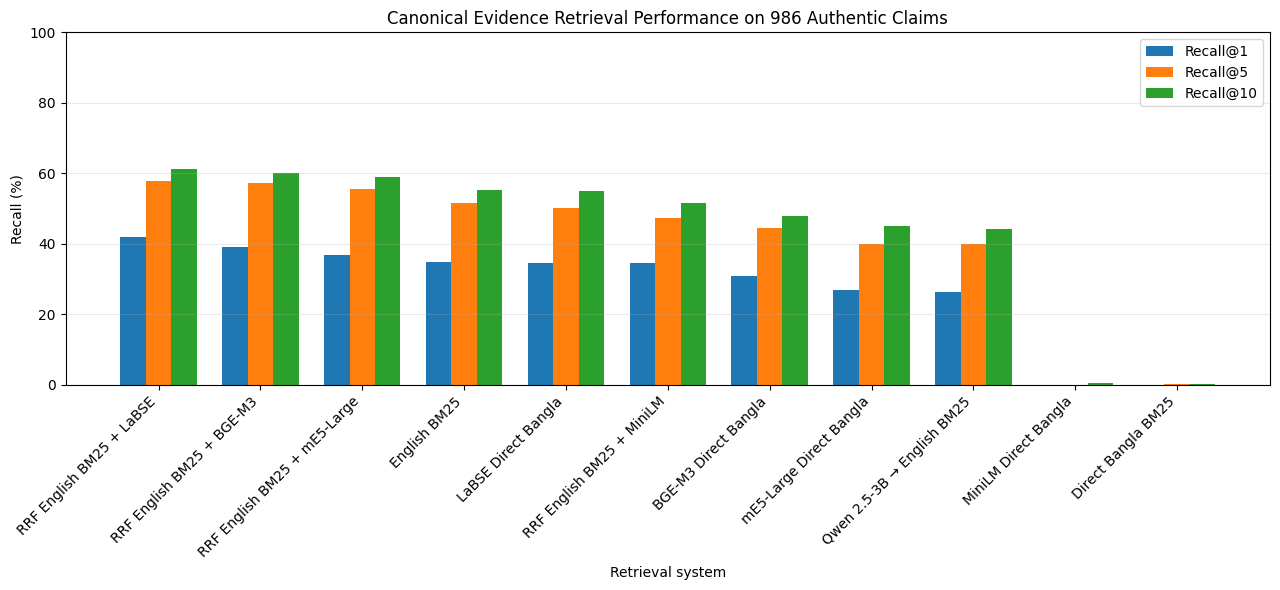

In [33]:
# ============================================================
# FIGURE 1 — GLOBAL RETRIEVAL PERFORMANCE
# Recall@1 / Recall@5 / Recall@10
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

FIG_DIR = Path("results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plot_df = df_ret.copy()

# Convert to percentage
systems = plot_df["System"].tolist()
x = np.arange(len(systems))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))

ax.bar(
    x - width,
    plot_df["R@1"] * 100,
    width,
    label="Recall@1"
)

ax.bar(
    x,
    plot_df["R@5"] * 100,
    width,
    label="Recall@5"
)

ax.bar(
    x + width,
    plot_df["R@10"] * 100,
    width,
    label="Recall@10"
)

ax.set_ylabel("Recall (%)")
ax.set_xlabel("Retrieval system")
ax.set_title(
    "Canonical Evidence Retrieval Performance on 986 Authentic Claims"
)

ax.set_xticks(x)
ax.set_xticklabels(
    systems,
    rotation=45,
    ha="right"
)

ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig1_global_recall.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig1_global_recall.pdf",
    bbox_inches="tight"
)

plt.show()

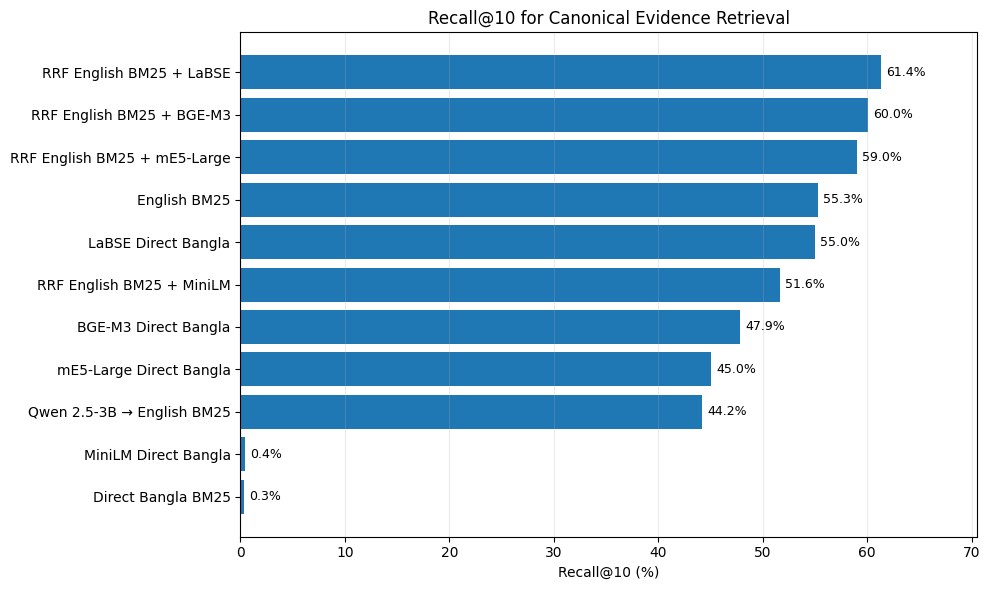

In [34]:
# ============================================================
# FIGURE 2 — RECALL@10 SYSTEM COMPARISON
# ============================================================

plot_df = (
    df_ret
    .sort_values("R@10", ascending=True)
    .copy()
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_df["System"],
    plot_df["R@10"] * 100
)

ax.set_xlabel("Recall@10 (%)")
ax.set_title(
    "Recall@10 for Canonical Evidence Retrieval"
)

ax.set_xlim(0, max(plot_df["R@10"] * 100) * 1.15)
ax.grid(axis="x", alpha=0.25)

# Add values
for bar, value in zip(
    bars,
    plot_df["R@10"] * 100
):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig2_recall10_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig2_recall10_comparison.pdf",
    bbox_inches="tight"
)

plt.show()

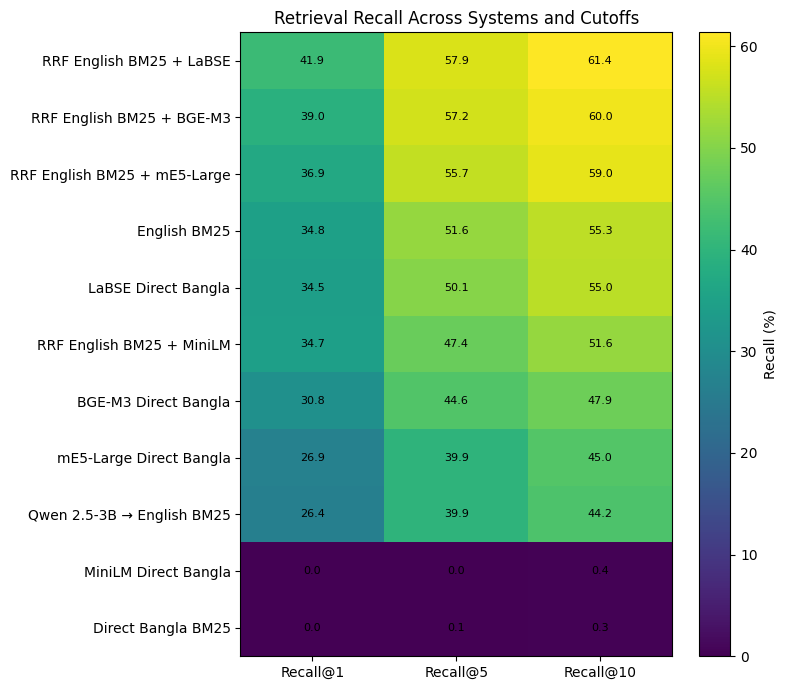

In [35]:
# ============================================================
# FIGURE 3 — RETRIEVAL PERFORMANCE HEATMAP
# ============================================================

heat_df = (
    df_ret
    .set_index("System")[["R@1", "R@5", "R@10"]]
    * 100
)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    heat_df.values,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(heat_df.columns))
)

ax.set_xticklabels(
    ["Recall@1", "Recall@5", "Recall@10"]
)

ax.set_yticks(
    np.arange(len(heat_df.index))
)

ax.set_yticklabels(
    heat_df.index
)

# Annotate cells
for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):

        value = heat_df.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title(
    "Retrieval Recall Across Systems and Cutoffs"
)

plt.colorbar(
    im,
    ax=ax,
    label="Recall (%)"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig3_retrieval_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig3_retrieval_heatmap.pdf",
    bbox_inches="tight"
)

plt.show()

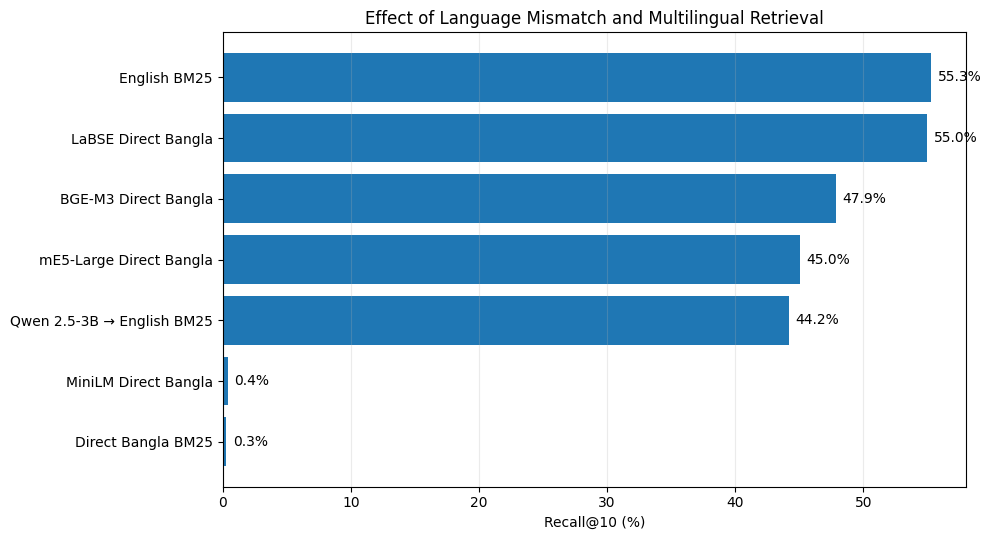

In [36]:
# ============================================================
# FIGURE 4 — LANGUAGE MISMATCH AND MULTILINGUAL RECOVERY
# ============================================================

selected = [
    "English BM25",
    "Direct Bangla BM25",
    "Qwen 2.5-3B → English BM25",
    "BGE-M3 Direct Bangla",
    "mE5-Large Direct Bangla",
    "LaBSE Direct Bangla",
    "MiniLM Direct Bangla"
]

available = [
    s for s in selected
    if s in df_ret["System"].values
]

plot_df = (
    df_ret[
        df_ret["System"].isin(available)
    ]
    .sort_values("R@10")
)

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(
    plot_df["System"],
    plot_df["R@10"] * 100
)

ax.set_xlabel("Recall@10 (%)")
ax.set_title(
    "Effect of Language Mismatch and Multilingual Retrieval"
)

ax.grid(axis="x", alpha=0.25)

for bar, value in zip(
    bars,
    plot_df["R@10"] * 100
):

    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig4_language_mismatch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig4_language_mismatch.pdf",
    bbox_inches="tight"
)

plt.show()

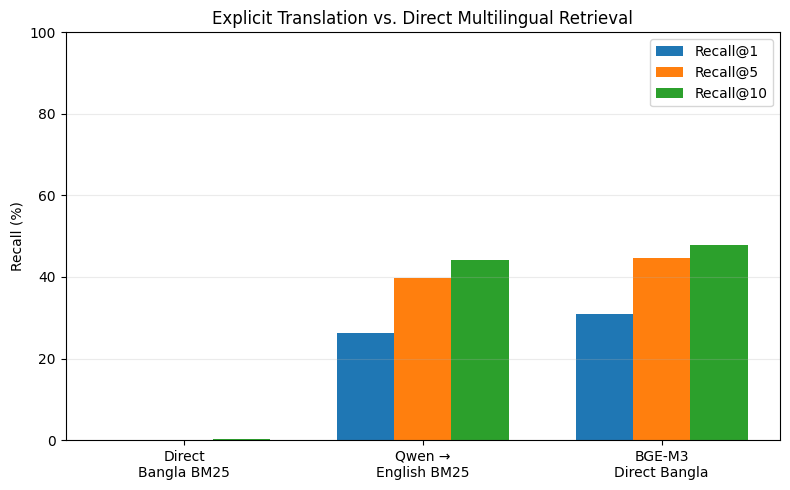

In [37]:
# ============================================================
# FIGURE 5 — TRANSLATION VS MULTILINGUAL RETRIEVAL
# ============================================================

core_order = [
    "Direct Bangla BM25",
    "Qwen 2.5-3B → English BM25",
    "BGE-M3 Direct Bangla"
]

core_df = (
    df_ret[
        df_ret["System"].isin(core_order)
    ]
    .set_index("System")
    .loc[core_order]
)

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(core_df))
width = 0.24

ax.bar(
    x - width,
    core_df["R@1"] * 100,
    width,
    label="Recall@1"
)

ax.bar(
    x,
    core_df["R@5"] * 100,
    width,
    label="Recall@5"
)

ax.bar(
    x + width,
    core_df["R@10"] * 100,
    width,
    label="Recall@10"
)

ax.set_xticks(x)
ax.set_xticklabels(
    [
        "Direct\nBangla BM25",
        "Qwen →\nEnglish BM25",
        "BGE-M3\nDirect Bangla"
    ]
)

ax.set_ylabel("Recall (%)")
ax.set_title(
    "Explicit Translation vs. Direct Multilingual Retrieval"
)

ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig5_translation_vs_bge.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig5_translation_vs_bge.pdf",
    bbox_inches="tight"
)

plt.show()

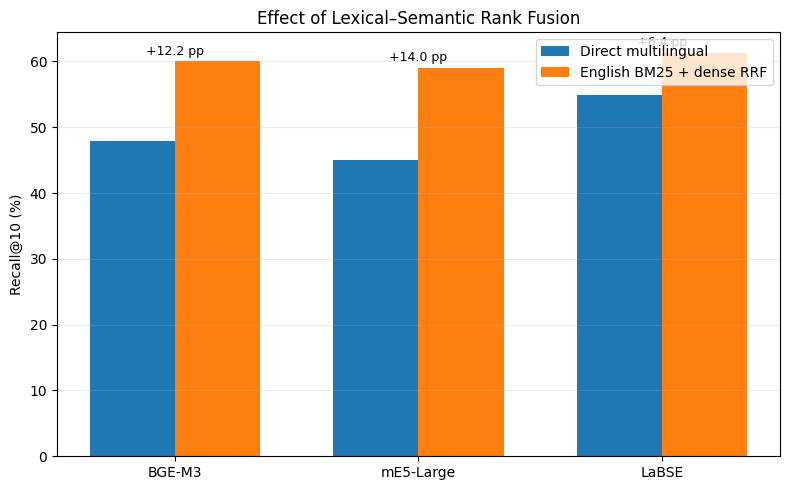

In [38]:
# ============================================================
# FIGURE 6 — RRF FUSION EFFECT
# ============================================================

rrf_models = [
    "BGE-M3",
    "mE5-Large",
    "LaBSE"
]

fusion_rows = []

for model in rrf_models:

    dense_name = f"{model} Direct Bangla"
    rrf_name = f"RRF English BM25 + {model}"

    if dense_name not in df_ret["System"].values:
        continue

    if rrf_name not in df_ret["System"].values:
        continue

    dense_r10 = float(
        df_ret.loc[
            df_ret["System"] == dense_name,
            "R@10"
        ].iloc[0]
    )

    rrf_r10 = float(
        df_ret.loc[
            df_ret["System"] == rrf_name,
            "R@10"
        ].iloc[0]
    )

    fusion_rows.append({
        "Model": model,
        "Standalone": dense_r10 * 100,
        "RRF": rrf_r10 * 100,
        "Gain": (rrf_r10 - dense_r10) * 100
    })

fusion_df = pd.DataFrame(fusion_rows)

x = np.arange(len(fusion_df))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - width / 2,
    fusion_df["Standalone"],
    width,
    label="Direct multilingual"
)

ax.bar(
    x + width / 2,
    fusion_df["RRF"],
    width,
    label="English BM25 + dense RRF"
)

ax.set_xticks(x)
ax.set_xticklabels(
    fusion_df["Model"]
)

ax.set_ylabel("Recall@10 (%)")
ax.set_title(
    "Effect of Lexical–Semantic Rank Fusion"
)

ax.grid(axis="y", alpha=0.25)
ax.legend()

for i, row in fusion_df.iterrows():

    ax.text(
        i,
        max(row["Standalone"], row["RRF"]) + 1,
        f"+{row['Gain']:.1f} pp",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig6_rrf_fusion_gain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig6_rrf_fusion_gain.pdf",
    bbox_inches="tight"
)

plt.show()

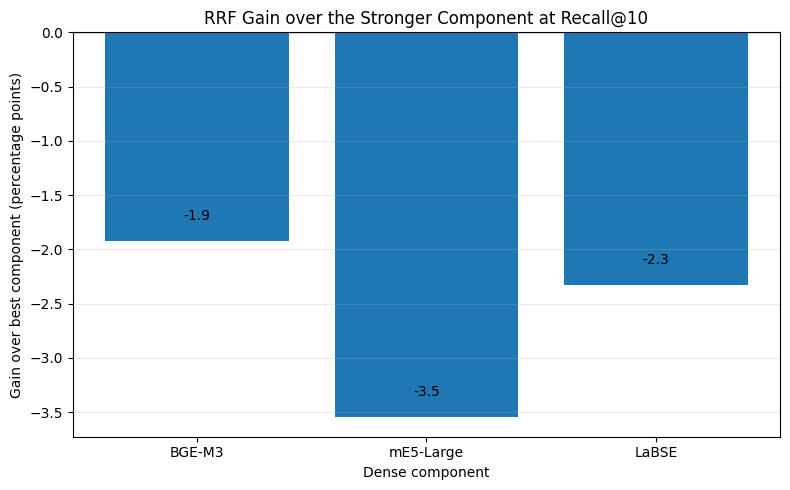

In [39]:
# ============================================================
# FIGURE 7 — RRF GAIN OVER STRONGER COMPONENT
# ============================================================

rrf10 = (
    df_rrf_ab[
        df_rrf_ab["k"] == 10
    ]
    .copy()
)

rrf10["Fusion"] = (
    rrf10["Fusion"]
    .str.replace(
        "RRF English BM25 + ",
        "",
        regex=False
    )
)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    rrf10["Fusion"],
    rrf10["Gain over best component"] * 100
)

ax.axhline(
    0,
    linewidth=1
)

ax.set_ylabel(
    "Gain over best component (percentage points)"
)

ax.set_xlabel(
    "Dense component"
)

ax.set_title(
    "RRF Gain over the Stronger Component at Recall@10"
)

ax.grid(axis="y", alpha=0.25)

for bar, value in zip(
    bars,
    rrf10["Gain over best component"] * 100
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f"{value:+.1f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig7_rrf_gain_best_component.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig7_rrf_gain_best_component.pdf",
    bbox_inches="tight"
)

plt.show()

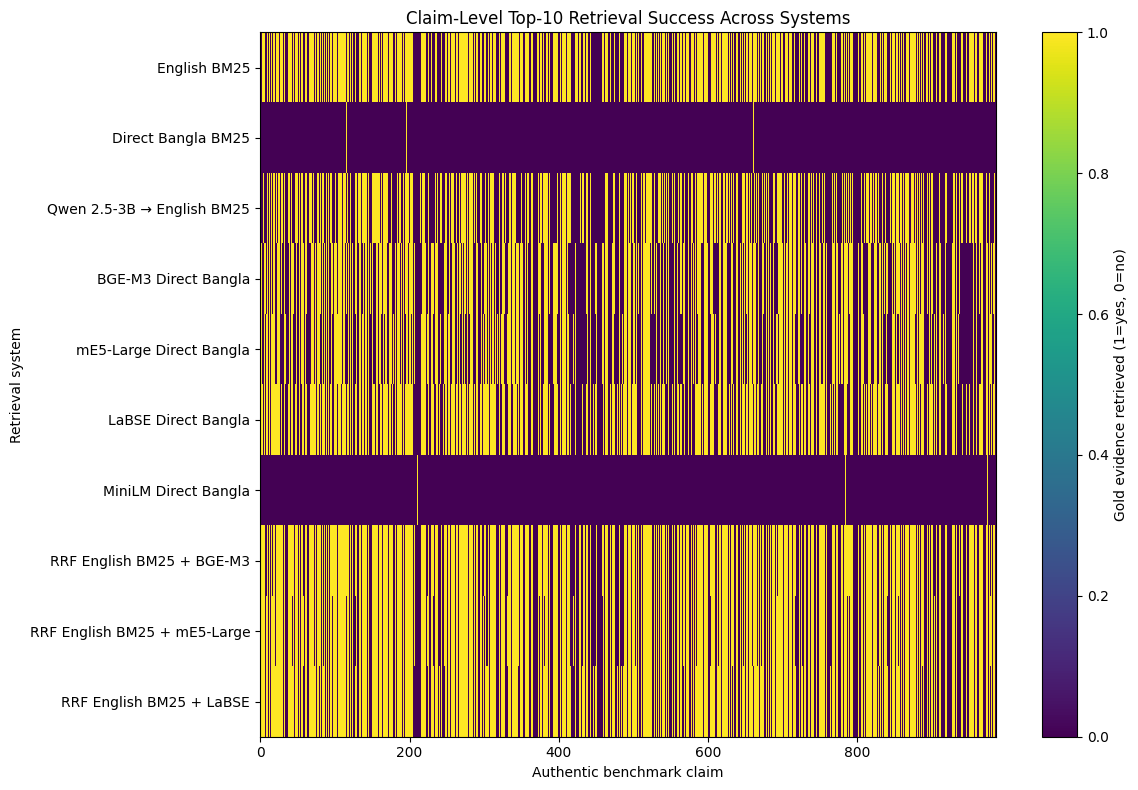

In [40]:
# ============================================================
# FIGURE 8 — CLAIM-LEVEL RETRIEVAL SUCCESS MATRIX
# ============================================================

systems_for_matrix = [
    "English BM25",
    "Direct Bangla BM25",
    "Qwen 2.5-3B → English BM25",
    "BGE-M3 Direct Bangla",
    "mE5-Large Direct Bangla",
    "LaBSE Direct Bangla",
    "MiniLM Direct Bangla",
    "RRF English BM25 + BGE-M3",
    "RRF English BM25 + mE5-Large",
    "RRF English BM25 + LaBSE"
]

systems_for_matrix = [
    s for s in systems_for_matrix
    if s in retrieval_results
]

matrix = []

for cid in gold_ids:

    row = []

    for system in systems_for_matrix:

        ranking = retrieval_results[system][cid]

        hit = any(
            eid in gold_ids[cid]
            for eid, _ in ranking[:10]
        )

        row.append(int(hit))

    matrix.append(row)

matrix = np.array(matrix)

# system-level success percentages
success_rates = matrix.mean(axis=0) * 100

fig, ax = plt.subplots(
    figsize=(12, 8)
)

im = ax.imshow(
    matrix.T,
    aspect="auto",
    interpolation="nearest"
)

ax.set_xlabel(
    "Authentic benchmark claim"
)

ax.set_ylabel(
    "Retrieval system"
)

ax.set_yticks(
    np.arange(len(systems_for_matrix))
)

ax.set_yticklabels(
    systems_for_matrix
)

ax.set_title(
    "Claim-Level Top-10 Retrieval Success Across Systems"
)

plt.colorbar(
    im,
    ax=ax,
    label="Gold evidence retrieved (1=yes, 0=no)"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig8_claim_retrieval_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig8_claim_retrieval_matrix.pdf",
    bbox_inches="tight"
)

plt.show()

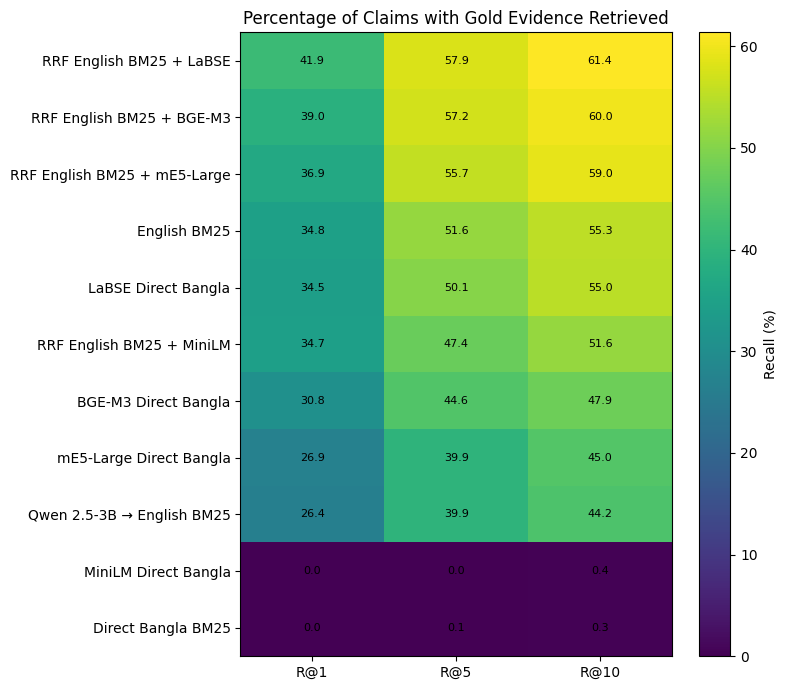

In [41]:
# ============================================================
# FIGURE 8B — SYSTEM × RETRIEVAL CUTOFF SUCCESS HEATMAP
# ============================================================

heat = (
    df_ret
    .set_index("System")[["R@1", "R@5", "R@10"]]
    * 100
)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    heat.values,
    aspect="auto"
)

ax.set_xticks(
    np.arange(3)
)

ax.set_xticklabels(
    ["R@1", "R@5", "R@10"]
)

ax.set_yticks(
    np.arange(len(heat))
)

ax.set_yticklabels(
    heat.index
)

for i in range(len(heat)):
    for j in range(3):

        ax.text(
            j,
            i,
            f"{heat.iloc[i, j]:.1f}",
            ha="center",
            va="center",
            fontsize=8
        )

ax.set_title(
    "Percentage of Claims with Gold Evidence Retrieved"
)

plt.colorbar(
    im,
    ax=ax,
    label="Recall (%)"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig8b_system_cutoff_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig8b_system_cutoff_heatmap.pdf",
    bbox_inches="tight"
)

plt.show()

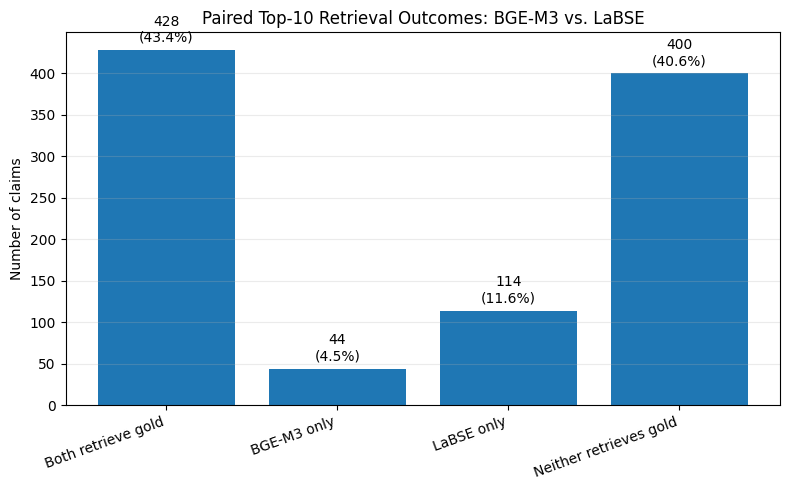

In [42]:
# ============================================================
# FIGURE 9 — BGE-M3 VS LABSE PAIRED OUTCOMES
# ============================================================

bge_name = "BGE-M3 Direct Bangla"
labse_name = "LaBSE Direct Bangla"

bge = retrieval_results[bge_name]
labse = retrieval_results[labse_name]

both = 0
bge_only = 0
labse_only = 0
neither = 0

for cid in gold_ids:

    bge_hit = any(
        eid in gold_ids[cid]
        for eid, _ in bge[cid][:10]
    )

    labse_hit = any(
        eid in gold_ids[cid]
        for eid, _ in labse[cid][:10]
    )

    if bge_hit and labse_hit:
        both += 1

    elif bge_hit:
        bge_only += 1

    elif labse_hit:
        labse_only += 1

    else:
        neither += 1

outcomes = pd.Series({
    "Both retrieve gold": both,
    "BGE-M3 only": bge_only,
    "LaBSE only": labse_only,
    "Neither retrieves gold": neither
})

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    outcomes.index,
    outcomes.values
)

ax.set_ylabel("Number of claims")
ax.set_title(
    "Paired Top-10 Retrieval Outcomes: BGE-M3 vs. LaBSE"
)

ax.set_xticklabels(
    outcomes.index,
    rotation=20,
    ha="right"
)

ax.grid(axis="y", alpha=0.25)

for bar, value in zip(
    bars,
    outcomes.values
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 10,
        f"{value}\n({value / len(gold_ids) * 100:.1f}%)",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig9_bge_labse_paired.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig9_bge_labse_paired.pdf",
    bbox_inches="tight"
)

plt.show()

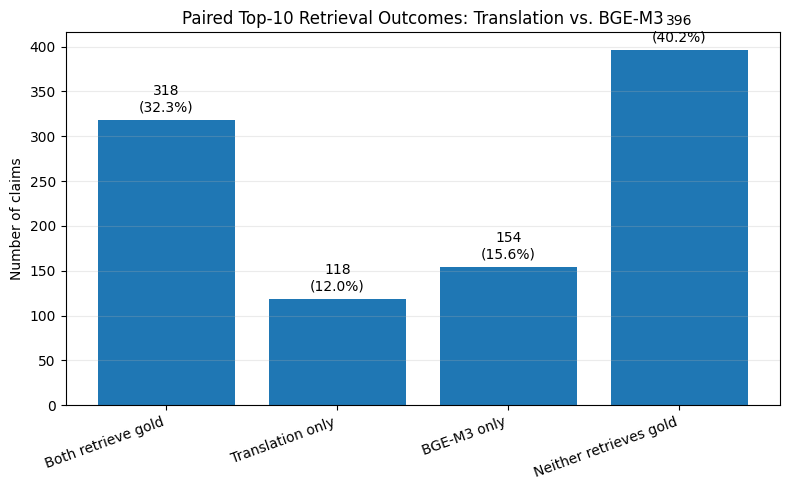

In [43]:
# ============================================================
# FIGURE 10 — TRANSLATION VS BGE-M3 PAIRED OUTCOMES
# ============================================================

translation_name = "Qwen 2.5-3B → English BM25"

translation = retrieval_results[translation_name]
bge = retrieval_results["BGE-M3 Direct Bangla"]

both = 0
translation_only = 0
bge_only = 0
neither = 0

for cid in gold_ids:

    translation_hit = any(
        eid in gold_ids[cid]
        for eid, _ in translation[cid][:10]
    )

    bge_hit = any(
        eid in gold_ids[cid]
        for eid, _ in bge[cid][:10]
    )

    if translation_hit and bge_hit:
        both += 1

    elif translation_hit:
        translation_only += 1

    elif bge_hit:
        bge_only += 1

    else:
        neither += 1

outcomes = pd.Series({
    "Both retrieve gold": both,
    "Translation only": translation_only,
    "BGE-M3 only": bge_only,
    "Neither retrieves gold": neither
})

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    outcomes.index,
    outcomes.values
)

ax.set_ylabel("Number of claims")
ax.set_title(
    "Paired Top-10 Retrieval Outcomes: Translation vs. BGE-M3"
)

ax.set_xticklabels(
    outcomes.index,
    rotation=20,
    ha="right"
)

ax.grid(axis="y", alpha=0.25)

for bar, value in zip(
    bars,
    outcomes.values
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 10,
        f"{value}\n({value / len(gold_ids) * 100:.1f}%)",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig10_translation_bge_paired.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig10_translation_bge_paired.pdf",
    bbox_inches="tight"
)

plt.show()

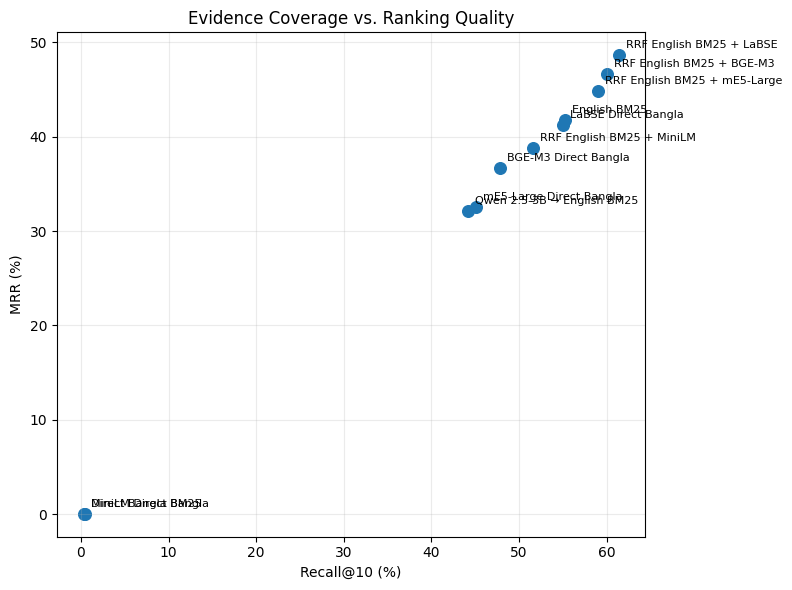

In [44]:
# ============================================================
# FIGURE 11 — MRR VS RECALL@10
# ============================================================

plot_df = df_ret.copy()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    plot_df["R@10"] * 100,
    plot_df["MRR"] * 100,
    s=70
)

for _, row in plot_df.iterrows():

    ax.annotate(
        row["System"],
        (
            row["R@10"] * 100,
            row["MRR"] * 100
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel("Recall@10 (%)")
ax.set_ylabel("MRR (%)")

ax.set_title(
    "Evidence Coverage vs. Ranking Quality"
)

ax.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig11_mrr_vs_recall10.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig11_mrr_vs_recall10.pdf",
    bbox_inches="tight"
)

plt.show()

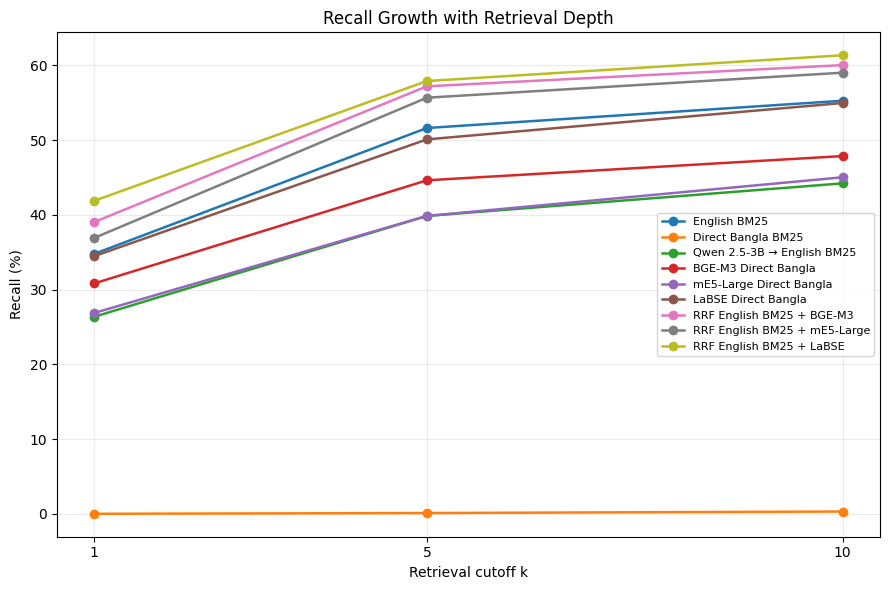

In [45]:
# ============================================================
# FIGURE 12 — RECALL CURVES
# ============================================================

systems_to_plot = [
    "English BM25",
    "Direct Bangla BM25",
    "Qwen 2.5-3B → English BM25",
    "BGE-M3 Direct Bangla",
    "mE5-Large Direct Bangla",
    "LaBSE Direct Bangla",
    "RRF English BM25 + BGE-M3",
    "RRF English BM25 + mE5-Large",
    "RRF English BM25 + LaBSE"
]

systems_to_plot = [
    s for s in systems_to_plot
    if s in df_ret["System"].values
]

fig, ax = plt.subplots(figsize=(9, 6))

k_values = [1, 5, 10]

for system in systems_to_plot:

    row = df_ret[
        df_ret["System"] == system
    ].iloc[0]

    recall_values = [
        row["R@1"] * 100,
        row["R@5"] * 100,
        row["R@10"] * 100
    ]

    ax.plot(
        k_values,
        recall_values,
        marker="o",
        linewidth=1.8,
        label=system
    )

ax.set_xticks(k_values)

ax.set_xlabel("Retrieval cutoff k")
ax.set_ylabel("Recall (%)")

ax.set_title(
    "Recall Growth with Retrieval Depth"
)

ax.grid(alpha=0.25)

ax.legend(
    fontsize=8,
    loc="best"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig12_recall_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig12_recall_curves.pdf",
    bbox_inches="tight"
)

plt.show()

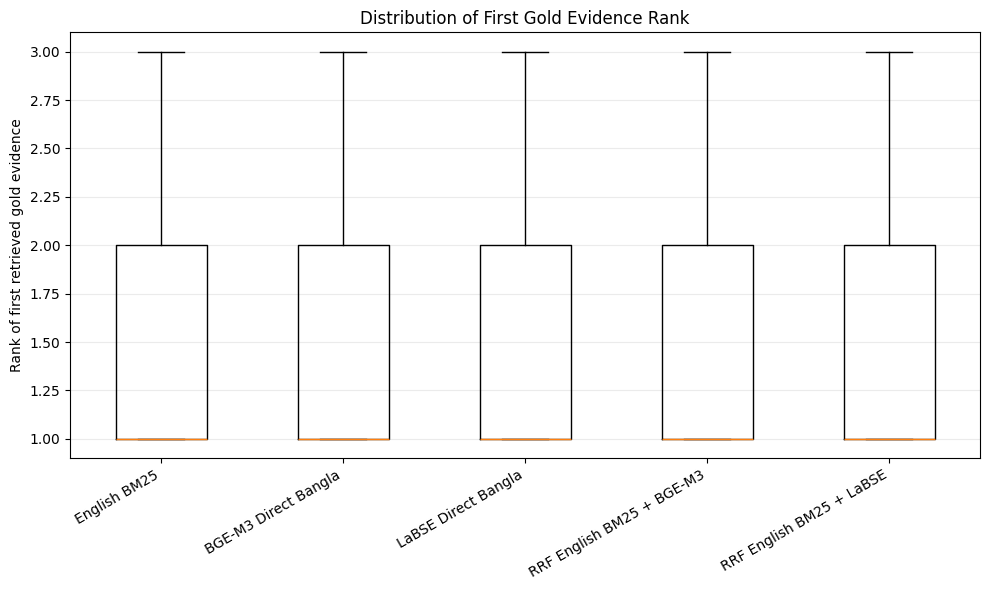

In [46]:
# ============================================================
# FIGURE 13 — FIRST GOLD EVIDENCE RANK DISTRIBUTION
# ============================================================

def first_gold_rank(
    results_by_claim,
    gold
):

    ranks = []

    for cid in gold:

        rank = None

        for i, (eid, _) in enumerate(
            results_by_claim[cid],
            start=1
        ):

            if eid in gold[cid]:

                rank = i
                break

        if rank is not None:
            ranks.append(rank)

    return np.array(ranks)


rank_systems = [
    "English BM25",
    "BGE-M3 Direct Bangla",
    "LaBSE Direct Bangla",
    "RRF English BM25 + BGE-M3",
    "RRF English BM25 + LaBSE"
]

fig, ax = plt.subplots(figsize=(10, 6))

rank_data = []

labels = []

for system in rank_systems:

    if system not in retrieval_results:
        continue

    ranks = first_gold_rank(
        retrieval_results[system],
        gold_ids
    )

    rank_data.append(ranks)
    labels.append(system)

ax.boxplot(
    rank_data,
    labels=labels,
    showfliers=False
)

ax.set_ylabel(
    "Rank of first retrieved gold evidence"
)

ax.set_title(
    "Distribution of First Gold Evidence Rank"
)

ax.set_xticklabels(
    labels,
    rotation=30,
    ha="right"
)

ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig13_first_gold_rank.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig13_first_gold_rank.pdf",
    bbox_inches="tight"
)

plt.show()

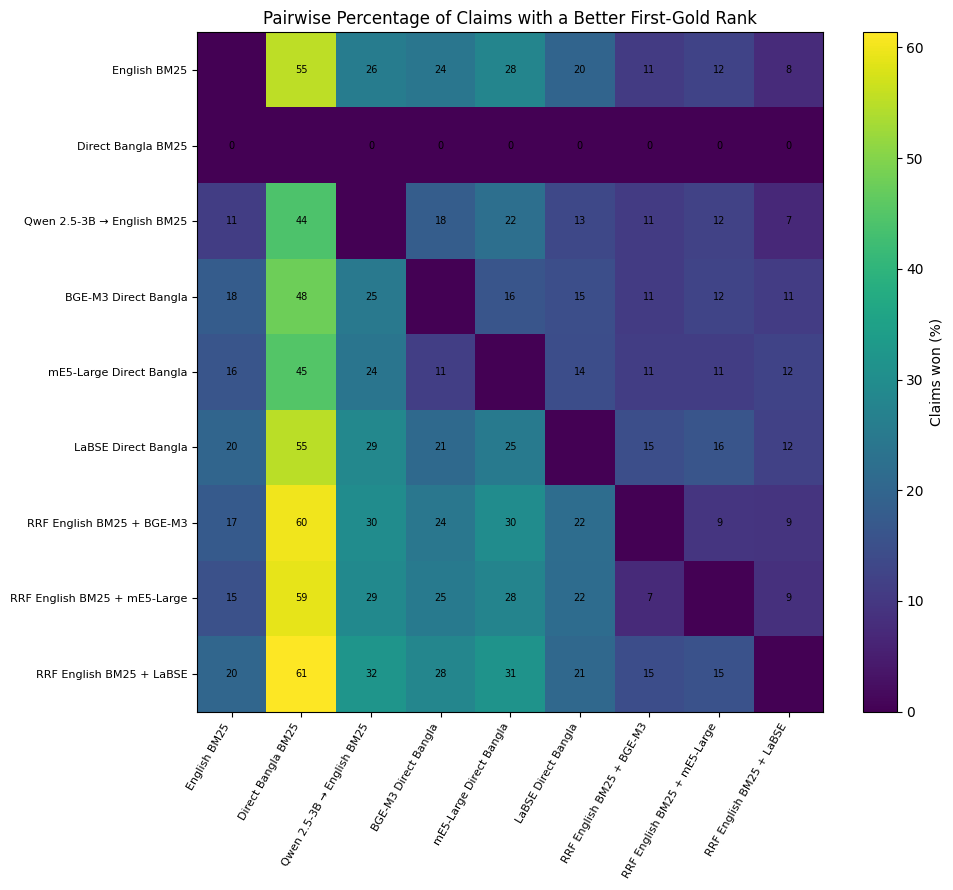

In [47]:
# ============================================================
# FIGURE 14 — PAIRWISE RETRIEVAL COMPARISON MATRIX
# ============================================================

def first_gold_rank_or_inf(
    ranking,
    gold
):

    for rank, (eid, _) in enumerate(
        ranking,
        start=1
    ):

        if eid in gold:
            return rank

    return np.inf


pair_systems = [
    "English BM25",
    "Direct Bangla BM25",
    "Qwen 2.5-3B → English BM25",
    "BGE-M3 Direct Bangla",
    "mE5-Large Direct Bangla",
    "LaBSE Direct Bangla",
    "RRF English BM25 + BGE-M3",
    "RRF English BM25 + mE5-Large",
    "RRF English BM25 + LaBSE"
]

pair_systems = [
    s for s in pair_systems
    if s in retrieval_results
]

# Score = number of claims where row system
# has a better first-gold rank than column system.

win_matrix = np.zeros(
    (len(pair_systems), len(pair_systems))
)

for i, system_a in enumerate(pair_systems):

    for j, system_b in enumerate(pair_systems):

        if i == j:
            continue

        wins = 0

        for cid in gold_ids:

            rank_a = first_gold_rank_or_inf(
                retrieval_results[system_a][cid],
                gold_ids[cid]
            )

            rank_b = first_gold_rank_or_inf(
                retrieval_results[system_b][cid],
                gold_ids[cid]
            )

            if rank_a < rank_b:
                wins += 1

        win_matrix[i, j] = (
            wins / len(gold_ids) * 100
        )

fig, ax = plt.subplots(
    figsize=(10, 9)
)

im = ax.imshow(
    win_matrix,
    aspect="auto"
)

ax.set_xticks(
    np.arange(len(pair_systems))
)

ax.set_yticks(
    np.arange(len(pair_systems))
)

ax.set_xticklabels(
    pair_systems,
    rotation=60,
    ha="right",
    fontsize=8
)

ax.set_yticklabels(
    pair_systems,
    fontsize=8
)

for i in range(len(pair_systems)):
    for j in range(len(pair_systems)):

        if i != j:

            ax.text(
                j,
                i,
                f"{win_matrix[i,j]:.0f}",
                ha="center",
                va="center",
                fontsize=7
            )

ax.set_title(
    "Pairwise Percentage of Claims with a Better First-Gold Rank"
)

plt.colorbar(
    im,
    ax=ax,
    label="Claims won (%)"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig14_pairwise_win_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig14_pairwise_win_matrix.pdf",
    bbox_inches="tight"
)

plt.show()

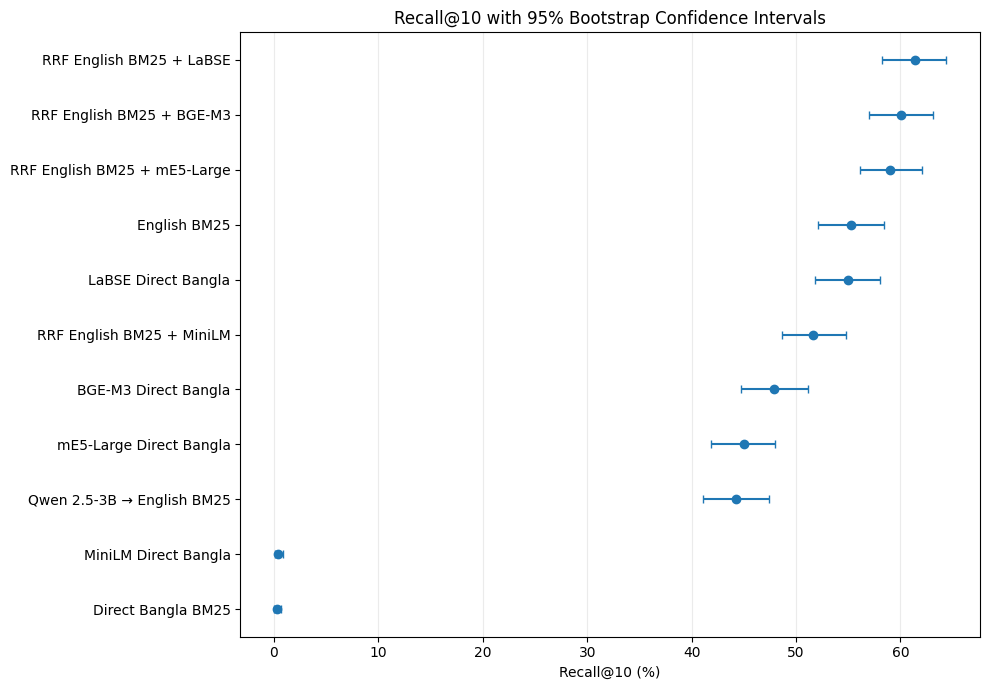

In [48]:
# ============================================================
# FIGURE 15 — RECALL@10 WITH BOOTSTRAP CI
# ============================================================

def bootstrap_recall_ci(
    hits,
    n_boot=2000,
    seed=42
):

    rng = np.random.default_rng(seed)

    n = len(hits)

    samples = rng.integers(
        0,
        n,
        size=(n_boot, n)
    )

    boot_means = hits[samples].mean(axis=1)

    return np.quantile(
        boot_means,
        [0.025, 0.975]
    )


ci_rows = []

for system in df_ret["System"]:

    hits = per_query_hit(
        retrieval_results[system],
        gold_ids,
        10
    )

    ci_low, ci_high = (
        bootstrap_recall_ci(hits)
        * 100
    )

    ci_rows.append({
        "System": system,
        "Recall": hits.mean() * 100,
        "CI_low": ci_low,
        "CI_high": ci_high
    })

ci_df = (
    pd.DataFrame(ci_rows)
    .sort_values("Recall")
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

y = np.arange(len(ci_df))

ax.errorbar(
    ci_df["Recall"],
    y,
    xerr=[
        ci_df["Recall"] - ci_df["CI_low"],
        ci_df["CI_high"] - ci_df["Recall"]
    ],
    fmt="o",
    capsize=3
)

ax.set_yticks(y)
ax.set_yticklabels(
    ci_df["System"]
)

ax.set_xlabel("Recall@10 (%)")
ax.set_title(
    "Recall@10 with 95% Bootstrap Confidence Intervals"
)

ax.grid(axis="x", alpha=0.25)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "fig15_recall10_confidence_intervals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    FIG_DIR / "fig15_recall10_confidence_intervals.pdf",
    bbox_inches="tight"
)

plt.show()

In [49]:
# ============================================================
# TRANSLATION ERROR ANALYSIS TABLE
# ============================================================

translation_examples = []

for rec in benchmark[:20]:

    cid = rec.claim_id

    translation_examples.append({
        "Claim ID": cid,
        "Bangla": rec.claims.get("bn", ""),
        "Qwen Translation": translated_queries.get(
            cid,
            ""
        )
    })

df_translation_examples = pd.DataFrame(
    translation_examples
)

display(df_translation_examples)

,Claim ID,Bangla,Qwen Translation
0,C0001,"আমি শুনেছি যে, যদি কেউ ইতিকাফে থাকে, তবে সে শু...","I have heard that if anyone is in ihram, they ..."
1,C0002,"যে ব্যক্তি হারামাইন শরীফাইনে মারা যায়, সে আমা...",Whoever dies in a state of ihram (pilgrimage) ...
2,C0003,নবী সাল্লাল্লাহু আলাইহি ওয়াসাল্লাম শুক্রবারের...,The Prophet ﷺ used to read Surahs Al-Insan and...
3,C0004,নবী মুহাম্মদ (সাল্লাল্লাহু আলাইহি ওয়াসাল্লাম)...,The Prophet Muhammad (SAW) said: When two pers...
4,C0005,নবী মুহাম্মদ (সা.) সূর্য অস্ত যাওয়ার সাথে সাথ...,The Prophet Muhammad (ﷺ) used to perform Maghr...
5,C0006,"একজন আনসারী ব্যক্তি, যার নাম ছিল সাআলাবা বিন আ...",A Companion named Salabah ibn Abdur Rahman acc...
6,C0007,"আমি দেখেছি, রাসূলুল্লাহ সাল্লাল্লাহু আলাইহি ওয...",I saw Allah's Messenger sallallahu alaihi wasa...
7,C0008,নবী মুহাম্মদ (সাল্লাল্লাহু আলাইহি ওয়া সাল্লাম...,The Prophet Muhammad (SAW) said: If a person w...
8,C0009,রাসূলুল্লাহ (সাল্লাল্লাহু আলাইহি ওয়া সাল্লাম)...,The Messenger of Allah (ﷺ) said: Zakat is not ...
9,C0010,"রাসূলুল্লাহ বলেছেন, তিনি সুলায়মান ইবনে বিলালে...",The Prophet said he mentioned the like of Yahy...


In [50]:
# ============================================================
# QUALITATIVE RETRIEVAL CASE
# Translation vs BGE-M3
# ============================================================

translation_name = "Qwen 2.5-3B → English BM25"
bge_name = "BGE-M3 Direct Bangla"

for rec in auth_with_gold:

    cid = rec.claim_id
    gold = gold_ids[cid]

    t_hit = any(
        eid in gold
        for eid, _ in retrieval_results[
            translation_name
        ][cid][:10]
    )

    b_hit = any(
        eid in gold
        for eid, _ in retrieval_results[
            bge_name
        ][cid][:10]
    )

    # Find a disagreement
    if t_hit != b_hit:

        print("=" * 80)
        print("CLAIM:", cid)
        print()
        print("BANGLA:")
        print(rec.claims.get("bn", ""))
        print()
        print("QWEN TRANSLATION:")
        print(translated_queries[cid])
        print()
        print("GOLD:")
        print(gold)
        print()

        print("TRANSLATION → BM25:")
        for rank, (eid, score) in enumerate(
            retrieval_results[
                translation_name
            ][cid][:5],
            start=1
        ):
            marker = "✓ GOLD" if eid in gold else ""
            print(
                f"{rank}. {eid} {marker}"
            )

        print()

        print("BGE-M3:")
        for rank, (eid, score) in enumerate(
            retrieval_results[
                bge_name
            ][cid][:5],
            start=1
        ):
            marker = "✓ GOLD" if eid in gold else ""
            print(
                f"{rank}. {eid} {marker}"
            )

        break

CLAIM: C0004

BANGLA:
নবী মুহাম্মদ (সাল্লাল্লাহু আলাইহি ওয়াসাল্লাম) বলেছেন, যখন দুই ব্যক্তি একটি লেনদেন সম্পন্ন করে, তখন তারা একে অপরের থেকে আলাদা না হওয়া পর্যন্ত বা তাদের লেনদেনের ক্ষেত্রে কোনো শর্ত না থাকলে, উভয়েরই লেনদেন বাতিল করার অধিকার থাকে।

QWEN TRANSLATION:
The Prophet Muhammad (SAW) said: When two persons conclude a transaction, their right to annul it until both are satisfied or there are no conditions in the transaction, belongs to both.

GOLD:
['muslim_3856', 'muslim_3855', 'bukhari_2112', 'muslim_3853', 'bukhari_2111']

TRANSLATION → BM25:
1. bukhari_2079 
2. muslim_2644 
3. bukhari_1813 
4. muslim_6544 
5. muslim_6545 

BGE-M3:
1. bukhari_2082 
2. bukhari_2112 ✓ GOLD
3. bukhari_2111 ✓ GOLD
4. bukhari_2109 
5. bukhari_2110 


In [51]:
# ============================================================
# FIGURE INVENTORY
# ============================================================

print("=" * 70)
print("GENERATED FIGURES")
print("=" * 70)

for path in sorted(FIG_DIR.glob("*")):

    size_kb = path.stat().st_size / 1024

    print(
        f"{path.name:<55} "
        f"{size_kb:>8.1f} KB"
    )

GENERATED FIGURES
fig10_translation_bge_paired.pdf                            17.3 KB
fig10_translation_bge_paired.png                           176.6 KB
fig11_mrr_vs_recall10.pdf                                   18.1 KB
fig11_mrr_vs_recall10.png                                  158.5 KB
fig12_recall_curves.pdf                                     20.9 KB
fig12_recall_curves.png                                    282.2 KB
fig13_first_gold_rank.pdf                                   14.3 KB
fig13_first_gold_rank.png                                  214.0 KB
fig14_pairwise_win_matrix.pdf                               23.3 KB
fig14_pairwise_win_matrix.png                              391.8 KB
fig15_recall10_confidence_intervals.pdf                     19.0 KB
fig15_recall10_confidence_intervals.png                    188.7 KB
fig1_global_recall.pdf                                      20.2 KB
fig1_global_recall.png                                     339.6 KB
fig2_recall10_comparison.pdf  

## 10. Export experiment artifacts

The exported tables include the complete retrieval matrix, translation-vs-BGE comparison, RRF ablation, and qualitative error-analysis cases.


In [52]:
# ============================================================
# FINAL COMPLETE EXPORT
# ============================================================

import shutil
from pathlib import Path

# ------------------------------------------------------------
# Create temporary export tree
# ------------------------------------------------------------

EXPORT_ROOT = Path(
    "HadithMisinfoBench_ICCIT2026_FINAL_EXPORT"
)

if EXPORT_ROOT.exists():
    shutil.rmtree(EXPORT_ROOT)

EXPORT_ROOT.mkdir()

# Copy experiment data
if Path("data").exists():
    shutil.copytree(
        "data",
        EXPORT_ROOT / "data"
    )

# Copy all results
if Path("results").exists():
    shutil.copytree(
        "results",
        EXPORT_ROOT / "results"
    )

# Copy notebook(s)
for notebook in Path(".").glob("*.ipynb"):
    shutil.copy2(
        notebook,
        EXPORT_ROOT / notebook.name
    )

# ------------------------------------------------------------
# Create final ZIP
# ------------------------------------------------------------

final_archive = shutil.make_archive(
    "HadithMisinfoBench_ICCIT2026_FINAL",
    "zip",
    root_dir=EXPORT_ROOT.parent,
    base_dir=EXPORT_ROOT.name
)

# ------------------------------------------------------------
# Size report
# ------------------------------------------------------------

size_mb = (
    Path(final_archive).stat().st_size
    / (1024 ** 2)
)

print("=" * 70)
print("FINAL ICCIT 2026 EXPORT")
print("=" * 70)

print(
    f"Archive: {final_archive}"
)

print(
    f"Size: {size_mb:.2f} MB"
)

print("\nIncluded:")
print("  ✓ data/processed/")
print("  ✓ data/indices/dense/")
print("  ✓ results/tables/")
print("  ✓ results/cache/")
print("  ✓ notebook(s), if present")
print("=" * 70)

FINAL ICCIT 2026 EXPORT
Archive: /content/HadithMisinfoBench_ICCIT2026_FINAL.zip
Size: 112.13 MB

Included:
  ✓ data/processed/
  ✓ data/indices/dense/
  ✓ results/tables/
  ✓ results/cache/
  ✓ notebook(s), if present


In [53]:
from google.colab import files

files.download("/content/HadithMisinfoBench_ICCIT2026_FINAL.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>